# HDAC8 QSAR: CatBoost weighted consensus (ECFP4, MACCS, RDKit, PubChem, Klekota–Roth)

Regression for HDAC8 pChEMBL on the scaffold-split sets `HDAC8_train.sdf` and `HDAC8_test.sdf`.

This notebook trains **one CatBoost per descriptor family** and combines their predictions with **non-negative weights that sum to 1** (`Consensus_weighted`). Weights are fit on out-of-fold training predictions only. The scaffold test set is not used for filtering, SHAP ranking, Optuna or the weights.

Naive concatenation of the five families is not used. Each family is reduced with a variance / correlation filter and a CV-SHAP + SHAP–mRMR pool, then modelled separately. The consensus is late fusion:

$$\hat y = \sum_f w_f\,\hat y_f,\qquad w_f \ge 0,\quad \sum_f w_f = 1$$

The applicability domain uses nearest-neighbour Tanimoto distance on the **concatenated SHAP–mRMR binary pools** (ECFP4, MACCS, PubChem, Klekota–Roth) — the same binary features that enter the consensus models — not the full raw fingerprints.

Descriptor matrices are loaded from `models/<Family>/` when present; otherwise they are recomputed.

Fitted family CatBoost models, SHAP–mRMR pools, consensus weights and auxiliary tables can be reloaded from `models/ConsensusCatBoost/` when `LOAD_TRAINED_MODELS=True` (set `FORCE_RETRAIN=True` to rebuild everything).


## 1. Imports and settings


In [57]:
from pathlib import Path
import json
import re
import shutil
import subprocess
import tempfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import optuna
import padelpy
import shap
from IPython.display import display
import ipywidgets as widgets
from catboost import CatBoostRegressor, Pool
from molvs import standardize_smiles
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Draw, MACCSkeys, rdFingerprintGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors
from scipy.optimize import minimize
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, permutation_test_score

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
ACTIVITY_PROP = "pchembl_value_mean"
TRAIN_SDF = Path("HDAC8_train.sdf")
TEST_SDF = Path("HDAC8_test.sdf")
MODEL_DIR = Path("models/ConsensusCatBoost")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FAMILIES = ["ECFP4", "MACCS", "RDKit", "PubChem", "KlekotaRoth"]
BINARY_FAMILIES = ["ECFP4", "MACCS", "PubChem", "KlekotaRoth"]

FP_RADIUS = 2
FP_SIZE_ECFP = 2048
FP_SIZE_MACCS = 167
FP_SIZE_PUBCHEM = 881
FP_SIZE_KR = 4860
DESC_SKIP = {"Ipc"}
PUBCHEM_XML = Path("fingerprints_xml/PubchemFingerprinter.xml")
KR_XML = Path("fingerprints_xml/KlekotaRothFingerprinter.xml")
PADEL_JAR = Path(padelpy.__file__).resolve().parent / "PaDEL-Descriptor" / "PaDEL-Descriptor.jar"

AD_Z = 0.5
CORR_TH = 0.95
MIN_ONBITS = 5
POOL_CAP = {
    "ECFP4": 200,
    "MACCS": 120,
    "RDKit": 100,
    "PubChem": 200,
    "KlekotaRoth": 250,
}

# Set True for a short debug run.
QUICK_RUN = False
# Set False to skip the expensive permutation test in section 11.
RUN_Y_RANDOMIZATION = True
# Set False to skip consensus SHAP interpretation in section 9.
RUN_CONSENSUS_SHAP = True
USE_CACHE = True
FORCE_RECOMPUTE = False
# Load fitted CatBoost members, consensus weights and auxiliary files from MODEL_DIR.
LOAD_TRAINED_MODELS = True
# Ignore MODEL_DIR cache and retrain SHAP pools, family CatBoosts and consensus.
FORCE_RETRAIN = False

N_SPLITS_SEARCH = 3 if QUICK_RUN else 5
N_TRIALS_FAMILY = 6 if QUICK_RUN else 20
N_PERMUTATIONS = 5 if QUICK_RUN else 20
PROBE_ITERATIONS = 150 if QUICK_RUN else 400
SHAP_PLOT_SAMPLES = 200 if QUICK_RUN else 800
SHAP_TOP_DESCRIPTORS = 20

cv_search = KFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
cv_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
rng = np.random.RandomState(SEED)


## 2. Data loading and curation

Molecules are sanitized and standardized with MolVS. Failed structures are dropped together with their activity values. The endpoint is `pchembl_value_mean` from the revision SDF files.


In [58]:
def load_sdf(path, activity_prop=ACTIVITY_PROP):
    supplier = Chem.ForwardSDMolSupplier(str(path), sanitize=False)
    rows, failed = [], []

    for i, mol in enumerate(supplier):
        rec = {"index": i + 1}
        if mol is None:
            failed.append({**rec, "reason": "unreadable record"})
            continue

        rec["chembl_id"] = mol.GetProp("molecule_chembl_id") if mol.HasProp("molecule_chembl_id") else f"mol_{i+1}"
        rec["smiles_raw"] = (
            mol.GetProp("canonical_smiles") if mol.HasProp("canonical_smiles") else Chem.MolToSmiles(mol)
        )
        rec["scaffold"] = mol.GetProp("scaffold") if mol.HasProp("scaffold") else ""
        try:
            rec["y"] = float(mol.GetProp(activity_prop))
        except Exception as exc:
            failed.append({**rec, "reason": f"missing/invalid {activity_prop}: {exc}"})
            continue

        try:
            Chem.SanitizeMol(mol)
            std_smi = standardize_smiles(Chem.MolToSmiles(mol))
            std_mol = Chem.MolFromSmiles(std_smi)
            if std_mol is None:
                raise ValueError("MolFromSmiles returned None after standardization")
        except Exception as exc:
            failed.append({**rec, "reason": str(exc)})
            continue

        rec.update({"mol": std_mol, "smiles": std_smi})
        rows.append(rec)

    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules ({len(failed)} failed)")
    return data, failed


train_df, train_failed = load_sdf(TRAIN_SDF)
test_df, test_failed = load_sdf(TEST_SDF)

display(train_failed if len(train_failed) else "No failed training molecules")
display(test_failed if len(test_failed) else "No failed test molecules")


HDAC8_train.sdf: kept 2092 / 2092 molecules (0 failed)
HDAC8_test.sdf: kept 524 / 524 molecules (0 failed)


'No failed training molecules'

'No failed test molecules'

Train: n = 2092, pChEMBL = 6.049 ± 0.883 [4.02, 9.92] 
Test: n = 524, pChEMBL = 6.051 ± 0.895 [4.01, 9.99] 


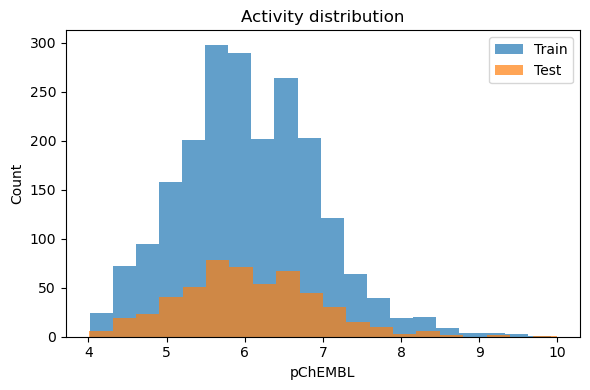

,index,chembl_id,smiles_raw,scaffold,y,mol,smiles
0,1,CHEMBL1767046,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...,,4.02,<rdkit.Chem.rdchem.Mol object at 0x00000246F04...,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...
1,2,CHEMBL1469,O=C(O)CCCc1ccccc1,,4.03,<rdkit.Chem.rdchem.Mol object at 0x00000246F04...,O=C(O)CCCc1ccccc1
2,3,CHEMBL3605493,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x00000246F04...,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...
3,4,CHEMBL1767047,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x00000246F04...,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...
4,5,CHEMBL3605499,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...,,4.08,<rdkit.Chem.rdchem.Mol object at 0x00000246F04...,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...


In [59]:
def summarize_split(name, df):
    print(
        f"{name}: n = {len(df)}, "
        f"pChEMBL = {df['y'].mean():.3f} ± {df['y'].std():.3f} "
        f"[{df['y'].min():.2f}, {df['y'].max():.2f}] "
    )


summarize_split("Train", train_df)
summarize_split("Test", test_df)


fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(train_df["y"], bins=20, alpha=0.7, label="Train")
ax.hist(test_df["y"], bins=20, alpha=0.7, label="Test")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Count")
ax.set_title("Activity distribution")
ax.legend()
plt.tight_layout()
plt.show()

y_tr = train_df["y"].to_numpy(dtype=np.float64)
y_ts = test_df["y"].to_numpy(dtype=np.float64)
train_df.head()


## 3. Multi-family descriptors

Five families are assembled with unique prefixes so names never collide.

| Family | Type | Source | Size |
|---|---|---|---|
| ECFP4 | binary hashed | RDKit Morgan r = 2, 2048 bits | 2048 |
| MACCS | binary keys | RDKit 167-bit MACCS | 167 |
| RDKit | continuous 2D | RDKit `Descriptors` (Ipc dropped) | ~200 |
| PubChem | binary keys | PaDEL `PubchemFingerprinter` | 881 |
| KlekotaRoth | binary keys | PaDEL `KlekotaRothFingerprinter` | 4860 |

Cached CSV matrices from the single-family notebooks are used when `USE_CACHE=True`. Training endpoints are checked against `y_tr` so a stale cache cannot silently misalign rows.


In [60]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE_ECFP)


def _write_smi(path, smiles, names):
    with path.open("w", encoding="ascii", newline="\n") as fh:
        for smi, name in zip(smiles, names):
            fh.write(f"{smi}\t{name}\n")


def _decode_java(raw):
    if not raw:
        return ""
    for enc in ("utf-8", "cp1251", "cp866"):
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")


def padel_fingerprints(smiles, names, tag, xml_src, expected_size, prefix):
    if not xml_src.is_file():
        raise FileNotFoundError(f"PaDEL XML not found: {xml_src.resolve()}")
    if not PADEL_JAR.is_file():
        raise FileNotFoundError(f"PaDEL JAR not found: {PADEL_JAR}")

    work = Path(tempfile.mkdtemp(prefix=f"hdac8_{tag}_"))
    try:
        smi_path = work / f"{tag}.smi"
        csv_path = work / f"{tag}.csv"
        xml_path = work / xml_src.name
        shutil.copy2(xml_src, xml_path)
        _write_smi(smi_path, smiles, names)
        cmd = [
            "java", "-Djava.awt.headless=true", "-Dfile.encoding=UTF-8",
            "-jar", str(PADEL_JAR),
            "-maxruntime", "-1", "-threads", "2",
            "-descriptortypes", str(xml_path),
            "-detectaromaticity",
            "-dir", str(smi_path),
            "-file", str(csv_path),
            "-fingerprints", "-retainorder",
        ]
        proc = subprocess.run(cmd, capture_output=True)
        stderr, stdout = _decode_java(proc.stderr), _decode_java(proc.stdout)
        if not csv_path.is_file() or csv_path.stat().st_size == 0:
            raise RuntimeError(
                f"PaDEL produced no output for {tag} (exit {proc.returncode}).\n"
                f"stderr:\n{stderr[:2000]}\nstdout:\n{stdout[:2000]}"
            )
        if proc.returncode != 0:
            print(f"PaDEL exited with {proc.returncode} for {tag}; CSV exists, continuing.")
        desc = pd.read_csv(csv_path)
        fp_cols = [c for c in desc.columns if c != "Name"]
        if len(fp_cols) != expected_size:
            raise ValueError(f"Expected {expected_size} bits for {prefix}, got {len(fp_cols)}")
        if len(desc) != len(smiles):
            raise ValueError(f"PaDEL returned {len(desc)} rows for {len(smiles)} molecules ({tag})")
        X = desc[fp_cols].to_numpy(dtype=np.float32)
        if not np.isfinite(X).all():
            raise ValueError(f"Non-finite bits in {tag}")
        return X, list(fp_cols)
    finally:
        shutil.rmtree(work, ignore_errors=True)


def compute_ecfp4(mols):
    X = np.vstack([np.asarray(mfpgen.GetFingerprint(mol), dtype=np.float32) for mol in mols])
    names = [f"ECFP4_{i}" for i in range(X.shape[1])]
    return X, names


def compute_maccs(mols):
    X = np.vstack([np.asarray(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32) for mol in mols])
    names = [f"MACCS_{i}" for i in range(X.shape[1])]
    return X, names


def compute_rdkit(mols_tr, mols_ts):
    desc_all = [name for name, _ in Descriptors.descList if name not in DESC_SKIP]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_all)
    X_tr = np.asarray([calc.CalcDescriptors(m) for m in mols_tr], dtype=np.float64)
    X_ts = np.asarray([calc.CalcDescriptors(m) for m in mols_ts], dtype=np.float64)
    X_tr[~np.isfinite(X_tr)] = np.nan
    X_ts[~np.isfinite(X_ts)] = np.nan
    df_tr = pd.DataFrame(X_tr, columns=desc_all)
    df_ts = pd.DataFrame(X_ts, columns=desc_all)
    nan_cols = df_tr.columns[df_tr.isna().any()].tolist()
    const_cols = df_tr.columns[df_tr.std(ddof=0) == 0].tolist()
    keep = [c for c in desc_all if c not in set(nan_cols) | set(const_cols)]
    X_tr = df_tr[keep].to_numpy(dtype=np.float64)
    X_ts = df_ts[keep].to_numpy(dtype=np.float64)
    if np.isnan(X_ts).any():
        med = np.nanmedian(X_tr, axis=0)
        mask = np.isnan(X_ts)
        X_ts[mask] = np.take(med, np.where(mask)[1])
    names = [f"RDKit_{c}" for c in keep]
    print(f"RDKit: kept {len(keep)} / {len(desc_all)} (dropped NaN={len(nan_cols)}, constant={len(const_cols)})")
    return X_tr.astype(np.float32), X_ts.astype(np.float32), names


def compute_padel(mols, xml_src, expected_size, tag):
    smiles = [Chem.MolToSmiles(mol) for mol in mols]
    names = [f"mol_{i+1}" for i in range(len(mols))]
    return padel_fingerprints(smiles, names, tag, xml_src, expected_size, tag)


def cache_paths(family):
    d = Path("models") / family
    return {
        "dir": d,
        "x_tr": d / f"x_tr_{family}.csv",
        "x_ts": d / f"x_ts_{family}.csv",
        "y_tr": d / "y_tr.csv",
        "names": d / "descriptor_names.csv",
    }


def default_names(family, n):
    if family == "ECFP4":
        return [f"ECFP4_{i}" for i in range(n)]
    if family == "MACCS":
        return [f"MACCS_{i}" for i in range(n)]
    if family == "PubChem":
        return [f"PubchemFP{i}" for i in range(n)]
    if family == "KlekotaRoth":
        return [f"KRFP{i}" for i in range(1, n + 1)]
    return [f"{family}_{i}" for i in range(n)]


def load_cached(family):
    p = cache_paths(family)
    if not (p["x_tr"].is_file() and p["x_ts"].is_file()):
        return None
    X_tr = np.loadtxt(p["x_tr"], delimiter=",")
    X_ts = np.loadtxt(p["x_ts"], delimiter=",")
    if p["y_tr"].is_file():
        y_cached = np.loadtxt(p["y_tr"], delimiter=",")
        if y_cached.shape[0] != y_tr.shape[0] or not np.allclose(y_cached, y_tr):
            raise ValueError(f"{family}: cached y_tr does not match the SDF training endpoint.")
    if p["names"].is_file():
        raw = pd.read_csv(p["names"])["descriptor"].astype(str).tolist()
        if family == "RDKit":
            names = [f"RDKit_{n}" if not str(n).startswith("RDKit_") else str(n) for n in raw]
        else:
            names = list(raw)
    else:
        names = default_names(family, X_tr.shape[1])
    if len(names) != X_tr.shape[1]:
        names = default_names(family, X_tr.shape[1])
    names = [f"{family}::{n}" for n in names]
    print(f"{family}: loaded cache {X_tr.shape} / {X_ts.shape}")
    return X_tr.astype(np.float32), X_ts.astype(np.float32), names


def compute_family(family):
    mols_tr, mols_ts = train_df["mol"], test_df["mol"]
    if family == "ECFP4":
        X_tr, names = compute_ecfp4(mols_tr)
        X_ts, _ = compute_ecfp4(mols_ts)
    elif family == "MACCS":
        X_tr, names = compute_maccs(mols_tr)
        X_ts, _ = compute_maccs(mols_ts)
    elif family == "RDKit":
        X_tr, X_ts, names = compute_rdkit(mols_tr, mols_ts)
        names = list(names)
    elif family == "PubChem":
        X_tr, raw = compute_padel(mols_tr, PUBCHEM_XML, FP_SIZE_PUBCHEM, "pubchem_train")
        X_ts, _ = compute_padel(mols_ts, PUBCHEM_XML, FP_SIZE_PUBCHEM, "pubchem_test")
        names = list(raw)
    elif family == "KlekotaRoth":
        X_tr, raw = compute_padel(mols_tr, KR_XML, FP_SIZE_KR, "kr_train")
        X_ts, _ = compute_padel(mols_ts, KR_XML, FP_SIZE_KR, "kr_test")
        names = list(raw)
    else:
        raise ValueError(family)
    names = [f"{family}::{n}" for n in names]
    print(f"{family}: computed {X_tr.shape} / {X_ts.shape}")
    return X_tr.astype(np.float32), X_ts.astype(np.float32), names


blocks = {}
for fam in FAMILIES:
    loaded = None
    if USE_CACHE and not FORCE_RECOMPUTE:
        loaded = load_cached(fam)
    if loaded is None:
        loaded = compute_family(fam)
    Xtr, Xts, names = loaded
    if Xtr.shape[0] != len(train_df) or Xts.shape[0] != len(test_df):
        raise ValueError(f"{fam}: row count mismatch with SDF tables")
    if Xtr.shape[1] != Xts.shape[1] or Xtr.shape[1] != len(names):
        raise ValueError(f"{fam}: column mismatch")
    blocks[fam] = {"X_tr": Xtr, "X_ts": Xts, "names": names}
    print(f"  mean |x| / mol: train {np.abs(Xtr).sum(1).mean():.1f}, test {np.abs(Xts).sum(1).mean():.1f}")

print("Total raw features:", sum(blocks[f]["X_tr"].shape[1] for f in FAMILIES))


ECFP4: loaded cache (2092, 2048) / (524, 2048)
  mean |x| / mol: train 51.0, test 49.8
MACCS: loaded cache (2092, 167) / (524, 167)
  mean |x| / mol: train 54.5, test 53.7
RDKit: loaded cache (2092, 202) / (524, 202)
  mean |x| / mol: train 3845.2, test 3750.7
PubChem: loaded cache (2092, 881) / (524, 881)
  mean |x| / mol: train 157.5, test 153.7
KlekotaRoth: loaded cache (2092, 4860) / (524, 4860)
  mean |x| / mol: train 59.6, test 58.7
Total raw features: 8158


## 4. Shared utilities

OECD-style metrics: $R^2$ on the training set, $Q^2$ from cross-validation, and external $R^2$ on the held-out scaffold test set.

**Applicability domain.** After SHAP–mRMR pools are built (section 6), the **selected binary pool features** of ECFP4, MACCS, PubChem and Klekota–Roth are concatenated and compared with Tanimoto distance $D_{\mathrm{Tanimoto}} = 1 - T_c$ (k = 1), threshold $\bar{d} + 0.5\,\sigma$ on training nearest neighbours. The AD is therefore defined in the same binary input space used by the consensus models (not the full raw fingerprints). RDKit 2D descriptors are excluded from the AD metric. In-AD membership means similarity to the training pooled-fingerprint space, not that an individual prediction is reliable.


In [61]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mean_t, mean_p = y_true.mean(), y_pred.mean()
    var_t, var_p = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mean_t) * (y_pred - mean_p))
    denom = var_t + var_p + (mean_t - mean_p) ** 2
    return float(2 * cov / denom) if denom else np.nan


def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "CCC": ccc(y_true, y_pred),
    }


def tanimoto_distance(X, Y=None):
    X = np.asarray(X, dtype=np.float64)
    Y = X if Y is None else np.asarray(Y, dtype=np.float64)
    intersection = X @ Y.T
    x_pop = X.sum(axis=1, keepdims=True)
    y_pop = Y.sum(axis=1, keepdims=True)
    union = x_pop + y_pop.T - intersection
    tc = np.divide(intersection, union, out=np.ones_like(intersection), where=union > 0)
    return 1.0 - tc


def compute_ad(X_train, z=AD_Z):
    dist = tanimoto_distance(X_train)
    np.fill_diagonal(dist, np.inf)
    nn = dist.min(axis=1)
    limit = float(nn.mean() + z * nn.std(ddof=0))
    return limit, nn


def apply_ad(X_train, X_test, limit):
    dist = tanimoto_distance(X_test, X_train)
    nn = dist.min(axis=1)
    return nn <= limit, nn


def plot_obs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))
    lo = min(y_true.min(), y_pred.min()) - 0.2
    hi = max(y_true.max(), y_pred.max()) + 0.2
    ax.scatter(y_true, y_pred, s=16, alpha=0.65, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], color="black", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed pChEMBL")
    ax.set_ylabel("Predicted pChEMBL")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return ax


def probe_catboost(**extra):
    params = dict(
        iterations=PROBE_ITERATIONS,
        depth=6,
        learning_rate=0.08,
        l2_leaf_reg=3.0,
        random_seed=SEED,
        verbose=False,
        loss_function="RMSE",
        allow_writing_files=False,
        thread_count=-1,
    )
    params.update(extra)
    return CatBoostRegressor(**params)


def make_catboost(params):
    return CatBoostRegressor(
        **params,
        random_seed=SEED,
        verbose=False,
        loss_function="RMSE",
        allow_writing_files=False,
    )


def cv_r2(estimator, X, y, cv, fit_params=None):
    fit_params = fit_params or {}
    scores = []
    for tr_idx, va_idx in cv.split(X, y):
        model = clone(estimator)
        model.fit(X[tr_idx], y[tr_idx], **fit_params)
        pred = model.predict(X[va_idx])
        scores.append(r2_score(y[va_idx], pred))
    return float(np.mean(scores))


def cv_r2_pruned(trial, factory, X, y, cv, fit_params=None):
    fit_params = fit_params or {}
    scores = []
    for step, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        model = factory()
        model.fit(X[tr_idx], y[tr_idx], **fit_params)
        pred = model.predict(X[va_idx])
        scores.append(r2_score(y[va_idx], pred))
        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


def run_study(name, objective, n_trials):
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=name)

    bar = widgets.IntProgress(value=0, min=0, max=n_trials, description=name[:20], bar_style="info")
    label = widgets.HTML(value="starting&hellip;")
    display(widgets.HBox([bar, label]))

    def on_trial(study, trial):
        bar.value = len(study.trials)
        if trial.state.name == "PRUNED":
            label.value = f"trial {trial.number} pruned; best CV R² = {study.best_value:.4f}"
        elif trial.value is not None:
            label.value = (
                f"trial {trial.number}: CV R² = {trial.value:.4f}; "
                f"best = {study.best_value:.4f} (trial {study.best_trial.number})"
            )
        if bar.value >= n_trials:
            bar.bar_style = "success"

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[on_trial])
    print(f"{name}: best CV R2 = {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


def evaluate_model(name, estimator, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=None, cv_fit_params=None):
    fit_params = fit_params or {}
    cv_fit_params = cv_fit_params or {}
    model = clone(estimator)
    model.fit(X_tr, y_tr, **fit_params)

    y_hat_tr = model.predict(X_tr)
    y_hat_cv = cross_val_predict(clone(estimator), X_tr, y_tr, cv=cv_final, n_jobs=1, params=cv_fit_params)
    y_hat_ts = model.predict(X_ts)

    train_m = regression_metrics(y_tr, y_hat_tr)
    cv_m = regression_metrics(y_tr, y_hat_cv)
    test_m = regression_metrics(y_ts, y_hat_ts)

    coverage = float(in_ad.mean()) if len(in_ad) else np.nan
    if in_ad.any():
        ad_m = regression_metrics(y_ts[in_ad], y_hat_ts[in_ad])
    else:
        ad_m = {k: np.nan for k in test_m}

    row = {
        "model": name,
        "R2_train": train_m["R2"],
        "RMSE_train": train_m["RMSE"],
        "Q2_CV": cv_m["R2"],
        "RMSE_CV": cv_m["RMSE"],
        "MAE_CV": cv_m["MAE"],
        "R2_ext": test_m["R2"],
        "RMSE_ext": test_m["RMSE"],
        "MAE_ext": test_m["MAE"],
        "CCC_ext": test_m["CCC"],
        "R2_ext_AD": ad_m["R2"],
        "RMSE_ext_AD": ad_m["RMSE"],
        "AD_coverage": coverage,
    }

    print(pd.Series(row).to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
    plot_obs_pred(y_tr, y_hat_tr, f"{name} train  R2={train_m['R2']:.3f}", ax=axes[0])
    plot_obs_pred(y_tr, y_hat_cv, f"{name} 5-fold CV  Q2={cv_m['R2']:.3f}", ax=axes[1])
    plot_obs_pred(y_ts, y_hat_ts, f"{name} test  R2={test_m['R2']:.3f}", ax=axes[2])
    if (~in_ad).any():
        axes[2].scatter(
            y_ts[~in_ad],
            y_hat_ts[~in_ad],
            s=28,
            facecolors="none",
            edgecolors="crimson",
            label="outside training space (AD)",
        )
        axes[2].legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
    write_test_predictions(name, y_hat_ts)
    return model, row, {"train": y_hat_tr, "cv": y_hat_cv, "test": y_hat_ts}


def write_test_predictions(name, y_hat_ts):
    pred_table[f"pred_{name}"] = np.asarray(y_hat_ts)
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)
    print(f"Updated {MODEL_DIR / 'test_predictions.csv'} with pred_{name}")
    cols = ["chembl_id", "pchembl_obs", f"pred_{name}", "in_AD", "D_Tanimoto", "T_c"]
    cols = [c for c in cols if c in pred_table.columns]
    display(pred_table[cols].head())


def attach_ad_columns(table, in_ad_mask, nn_dist):
    table = table.copy()
    table["in_AD"] = in_ad_mask
    table["D_Tanimoto"] = nn_dist
    table["T_c"] = 1.0 - nn_dist
    return table


def write_consensus_supplementary(y_hat_tr, y_hat_cv, y_hat_ts, model_name="Consensus_weighted"):
    """Export actual vs predicted pIC50 (mean pChEMBL) for supplementary outlier checks."""
    y_hat_tr = np.asarray(y_hat_tr, dtype=float)
    y_hat_cv = np.asarray(y_hat_cv, dtype=float)
    y_hat_ts = np.asarray(y_hat_ts, dtype=float)

    train_out = train_pred_table.copy()
    train_out["pIC50_obs"] = y_tr
    train_out["pIC50_pred"] = y_hat_tr
    train_out["pIC50_pred_cv"] = y_hat_cv
    train_out["residual"] = train_out["pIC50_obs"] - train_out["pIC50_pred"]
    train_out["residual_cv"] = train_out["pIC50_obs"] - train_out["pIC50_pred_cv"]
    train_path = MODEL_DIR / "consensus_train_predictions.csv"
    train_out.to_csv(train_path, index=False)

    test_out = pred_table.copy()
    test_out["pIC50_obs"] = y_ts
    test_out["pIC50_pred"] = y_hat_ts
    test_out["residual"] = test_out["pIC50_obs"] - test_out["pIC50_pred"]
    test_path = MODEL_DIR / "consensus_test_predictions.csv"
    test_out.to_csv(test_path, index=False)

    print(f"Wrote supplementary train predictions: {train_path}")
    print(f"Wrote supplementary test predictions: {test_path}")
    display(
        pd.DataFrame(
            {
                "split": ["train", "train (5-fold CV)", "test"],
                "model": [model_name, model_name, model_name],
                "n": [len(y_tr), len(y_tr), len(y_ts)],
                "R2": [
                    r2_score(y_tr, y_hat_tr),
                    r2_score(y_tr, y_hat_cv),
                    r2_score(y_ts, y_hat_ts),
                ],
                "RMSE": [
                    rmse(y_tr, y_hat_tr),
                    rmse(y_tr, y_hat_cv),
                    rmse(y_ts, y_hat_ts),
                ],
            }
        ).round(4)
    )


def metrics_from_preds(name, y_hat_tr, y_hat_cv, y_hat_ts, in_ad):
    train_m = regression_metrics(y_tr, y_hat_tr)
    cv_m = regression_metrics(y_tr, y_hat_cv)
    test_m = regression_metrics(y_ts, y_hat_ts)
    ad_m = regression_metrics(y_ts[in_ad], y_hat_ts[in_ad]) if in_ad.any() else {k: np.nan for k in test_m}
    row = {
        "model": name,
        "R2_train": train_m["R2"],
        "RMSE_train": train_m["RMSE"],
        "Q2_CV": cv_m["R2"],
        "RMSE_CV": cv_m["RMSE"],
        "MAE_CV": cv_m["MAE"],
        "R2_ext": test_m["R2"],
        "RMSE_ext": test_m["RMSE"],
        "MAE_ext": test_m["MAE"],
        "CCC_ext": test_m["CCC"],
        "R2_ext_AD": ad_m["R2"],
        "RMSE_ext_AD": ad_m["RMSE"],
        "AD_coverage": float(in_ad.mean()),
    }
    print(pd.Series(row).to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
    plot_obs_pred(y_tr, y_hat_tr, f"{name} train  R2={train_m['R2']:.3f}", ax=axes[0])
    plot_obs_pred(y_tr, y_hat_cv, f"{name} 5-fold CV  Q2={cv_m['R2']:.3f}", ax=axes[1])
    plot_obs_pred(y_ts, y_hat_ts, f"{name} test  R2={test_m['R2']:.3f}", ax=axes[2])
    plt.tight_layout()
    plt.show()
    write_test_predictions(name, y_hat_ts)
    return row


WORKSPACE_META_PATH = MODEL_DIR / "workspace_meta.json"
POOLS_PATH = MODEL_DIR / "pools.pkl"
FAMILY_PREDS_PATH = MODEL_DIR / "family_predictions.pkl"
RESULTS_PATH = MODEL_DIR / "results.pkl"


def _family_model_paths():
    return {fam: MODEL_DIR / f"CatBoost_{fam}.pkl" for fam in FAMILIES}


def consensus_models_ready():
    paths = list(_family_model_paths().values()) + [
        MODEL_DIR / "pool_feature_names.pkl",
        MODEL_DIR / "consensus_weights.pkl",
        MODEL_DIR / "ad_meta.json",
        MODEL_DIR / "x_ad_tr.npz",
    ]
    return all(p.is_file() for p in paths)


def write_workspace_meta(stage):
    meta = {
        "stage": stage,
        "seed": SEED,
        "n_train": int(len(train_df)),
        "n_test": int(len(test_df)),
        "families": list(FAMILIES),
        "activity_prop": ACTIVITY_PROP,
    }
    WORKSPACE_META_PATH.write_text(json.dumps(meta, indent=2), encoding="utf-8")


def validate_workspace_meta():
    if not WORKSPACE_META_PATH.is_file():
        return
    meta = json.loads(WORKSPACE_META_PATH.read_text(encoding="utf-8"))
    if meta.get("n_train") != len(train_df) or meta.get("n_test") != len(test_df):
        raise ValueError(
            "MODEL_DIR cache was built for a different train/test split. "
            "Set FORCE_RETRAIN=True or remove models/ConsensusCatBoost."
        )


def rebuild_pools_from_blocks():
    pool_names = joblib.load(MODEL_DIR / "pool_feature_names.pkl")
    pools = {}
    for fam in FAMILIES:
        names_all = list(blocks[fam]["names"])
        name_to_idx = {n: i for i, n in enumerate(names_all)}
        wanted = list(pool_names[fam])
        missing = [n for n in wanted if n not in name_to_idx]
        if missing:
            raise ValueError(f"{fam}: cached pool features not found in filtered blocks: {missing[:3]}")
        idx = np.asarray([name_to_idx[n] for n in wanted], dtype=int)
        pools[fam] = {
            "idx": idx,
            "names": wanted,
            "X_tr": blocks[fam]["X_tr"][:, idx],
            "X_ts": blocks[fam]["X_ts"][:, idx],
            "shap": np.full(len(wanted), np.nan, dtype=np.float64),
        }
    return pools


def load_pools_and_ad():
    validate_workspace_meta()
    if POOLS_PATH.is_file():
        pools = joblib.load(POOLS_PATH)
        print(f"Loaded pools from {POOLS_PATH}")
    else:
        pools = rebuild_pools_from_blocks()
        print("Rebuilt pools from pool_feature_names.pkl and filtered descriptor blocks")

    shap_rank = pd.read_csv(MODEL_DIR / "shap_rank_by_family.csv")
    ad_meta = json.loads((MODEL_DIR / "ad_meta.json").read_text(encoding="utf-8"))
    ad_limit = float(ad_meta["ad_limit"])

    X_ad_tr = np.hstack([(pools[f]["X_tr"] > 0).astype(np.float64) for f in BINARY_FAMILIES])
    X_ad_ts = np.hstack([(pools[f]["X_ts"] > 0).astype(np.float64) for f in BINARY_FAMILIES])
    _, nn_train = compute_ad(X_ad_tr)
    in_ad, nn_test = apply_ad(X_ad_tr, X_ad_ts, ad_limit)

    pred_table_path = MODEL_DIR / "test_predictions.csv"
    if pred_table_path.is_file():
        pred_table = pd.read_csv(pred_table_path)
        if len(pred_table) != len(test_df):
            raise ValueError("Cached test_predictions.csv row count does not match the SDF test set")
    else:
        pred_table = test_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()

    pred_table = attach_ad_columns(pred_table, in_ad, nn_test)

    return pools, shap_rank, in_ad, ad_limit, nn_train, nn_test, pred_table


def save_pools_and_ad(pools, shap_rank, in_ad, nn_test, ad_limit, nn_train, X_ad_tr):
    joblib.dump(pools, POOLS_PATH)
    joblib.dump({f: pools[f]["names"] for f in FAMILIES}, MODEL_DIR / "pool_feature_names.pkl")
    write_workspace_meta("pools")
    print(f"Saved {POOLS_PATH}")


def load_family_models_and_preds():
    global pred_table
    validate_workspace_meta()
    fitted = {fam: joblib.load(path) for fam, path in _family_model_paths().items()}
    print("Loaded family CatBoost models:", ", ".join(str(p) for p in _family_model_paths().values()))

    if FAMILY_PREDS_PATH.is_file():
        preds = joblib.load(FAMILY_PREDS_PATH)
        print(f"Loaded family predictions from {FAMILY_PREDS_PATH}")
    else:
        best_params = joblib.load(MODEL_DIR / "best_params.pkl")
        preds = {}
        for fam in FAMILIES:
            Xtr, Xts = pools[fam]["X_tr"], pools[fam]["X_ts"]
            model = fitted[fam]
            y_hat_tr = model.predict(Xtr)
            y_hat_ts = model.predict(Xts)
            est = make_catboost(best_params[fam])
            y_hat_cv = cross_val_predict(
                clone(est), Xtr, y_tr, cv=cv_final, n_jobs=1, params={"verbose": False}
            )
            preds[fam] = {"train": y_hat_tr, "cv": y_hat_cv, "test": y_hat_ts}
        joblib.dump(preds, FAMILY_PREDS_PATH)
        print(f"Recomputed and saved family predictions: {FAMILY_PREDS_PATH}")

    studies = joblib.load(MODEL_DIR / "optuna_studies.pkl") if (MODEL_DIR / "optuna_studies.pkl").is_file() else {}
    if RESULTS_PATH.is_file():
        results = joblib.load(RESULTS_PATH)
    else:
        results = []
        summary = pd.read_csv(MODEL_DIR / "metrics_summary.csv")
        for _, row in summary.iterrows():
            if str(row.get("model", "")).startswith("CatBoost_") and "Q2_CV" in row.index and pd.notna(row.get("Q2_CV")):
                results.append(row.to_dict())
        # Display-only CSV (R2/Q2cv headers) or empty rows: rebuild from cached preds.
        if len(results) < len(FAMILIES) and FAMILY_PREDS_PATH.is_file():
            results = [
                metrics_from_preds(
                    f"CatBoost_{fam}",
                    preds[fam]["train"],
                    preds[fam]["cv"],
                    preds[fam]["test"],
                    in_ad,
                )
                for fam in FAMILIES
            ]
            print(f"Rebuilt family metrics from {FAMILY_PREDS_PATH}")

    for fam in FAMILIES:
        pred_table[f"pred_CatBoost_{fam}"] = np.asarray(preds[fam]["test"])
    pred_table = attach_ad_columns(pred_table, in_ad, nn_test)
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)
    print(f"Synced family test predictions in {MODEL_DIR / 'test_predictions.csv'}")

    return fitted, preds, studies, results


def save_family_workspace(fitted, preds, studies, results):
    for fam, model in fitted.items():
        joblib.dump(model, MODEL_DIR / f"CatBoost_{fam}.pkl")
    joblib.dump(preds, FAMILY_PREDS_PATH)
    joblib.dump(results, RESULTS_PATH)
    joblib.dump({k: v.best_params for k, v in studies.items()}, MODEL_DIR / "best_params.pkl")
    joblib.dump(studies, MODEL_DIR / "optuna_studies.pkl")
    write_workspace_meta("family_models")
    print(f"Saved family workspace to {MODEL_DIR}")


def load_consensus_workspace():
    bundle = joblib.load(MODEL_DIR / "consensus_weights.pkl")
    w_cons = np.asarray(bundle["weights"], dtype=float)
    family_order = list(bundle["families"])
    w_table = pd.read_csv(MODEL_DIR / "consensus_simplex_weights.csv")
    display(w_table.round(4))

    P_tr = np.column_stack([preds[f]["train"] for f in family_order])
    P_cv = np.column_stack([preds[f]["cv"] for f in family_order])
    P_ts = np.column_stack([preds[f]["test"] for f in family_order])
    y_w_tr = P_tr @ w_cons
    y_w_cv = P_cv @ w_cons
    y_w_ts = P_ts @ w_cons
    preds["Consensus_weighted"] = {"train": y_w_tr, "cv": y_w_cv, "test": y_w_ts}

    consensus_name = "Consensus_weighted"
    if not any(r.get("model") == consensus_name for r in results):
        row = metrics_from_preds(consensus_name, y_w_tr, y_w_cv, y_w_ts, in_ad)
        results.append(row)
    write_consensus_supplementary(y_w_tr, y_w_cv, y_w_ts)
    print(f"Loaded consensus weights from {MODEL_DIR / 'consensus_weights.pkl'}")
    return w_cons, w_table, y_w_tr, y_w_cv, y_w_ts


CONSENSUS_SHAP_TRAIN_PATH = MODEL_DIR / "consensus_shap_train.npz"
CONSENSUS_SHAP_TEST_PATH = MODEL_DIR / "consensus_shap_test.npz"
CONSENSUS_SHAP_IMPORTANCE_PATH = MODEL_DIR / "consensus_shap_importance.csv"


def descriptor_display_id(name):
    """Strip family prefix from pooled descriptor name (Family::ID -> ID)."""
    return str(name).split("::", 1)[-1]


def descriptor_display_ids(names):
    return [descriptor_display_id(n) for n in names]


def build_consensus_feature_blocks(split="train"):
    key = "X_tr" if split == "train" else "X_ts"
    X_parts, names, slices = [], [], {}
    col = 0
    for fam in BINARY_FAMILIES:
        X_f = np.asarray(pools[fam][key], dtype=np.float32)
        slices[fam] = slice(col, col + X_f.shape[1])
        X_parts.append(X_f)
        names.extend(pools[fam]["names"])
        col += X_f.shape[1]
    return np.hstack(X_parts), names, slices


def compute_consensus_shap(X_by_family):
    """TreeSHAP per family CatBoost, scaled by simplex weights and concatenated."""
    blocks = []
    for fam in BINARY_FAMILIES:
        w = float(w_cons[FAMILIES.index(fam)])
        X_f = np.asarray(X_by_family[fam])
        explainer = shap.TreeExplainer(fitted[fam])
        sv = explainer.shap_values(X_f)
        if isinstance(sv, list):
            sv = sv[0]
        blocks.append(np.asarray(sv, dtype=np.float64) * w)
    return np.hstack(blocks)


def consensus_shap_importance(shap_values, feature_names):
    families = []
    for fam in BINARY_FAMILIES:
        families.extend([fam] * len(pools[fam]["names"]))
    return (
        pd.DataFrame(
            {
                "descriptor": descriptor_display_ids(feature_names),
                "family": families,
                "mean_abs_SHAP_consensus": np.abs(shap_values).mean(axis=0),
            }
        )
        .sort_values("mean_abs_SHAP_consensus", ascending=False)
        .reset_index(drop=True)
    )


def save_consensus_shap(shap_tr, shap_ts, feature_names, importance):
    np.savez_compressed(
        CONSENSUS_SHAP_TRAIN_PATH,
        shap=shap_tr,
        features=np.asarray(feature_names, dtype=object),
    )
    np.savez_compressed(
        CONSENSUS_SHAP_TEST_PATH,
        shap=shap_ts,
        features=np.asarray(feature_names, dtype=object),
    )
    importance.to_csv(CONSENSUS_SHAP_IMPORTANCE_PATH, index=False)
    print(f"Saved consensus SHAP: {CONSENSUS_SHAP_TRAIN_PATH.name}, {CONSENSUS_SHAP_TEST_PATH.name}")


def load_consensus_shap():
    tr = np.load(CONSENSUS_SHAP_TRAIN_PATH, allow_pickle=True)
    ts = np.load(CONSENSUS_SHAP_TEST_PATH, allow_pickle=True)
    importance = pd.read_csv(CONSENSUS_SHAP_IMPORTANCE_PATH)
    importance["descriptor"] = descriptor_display_ids(importance["descriptor"])
    feature_names = list(tr["features"])
    return tr["shap"], ts["shap"], feature_names, importance


CONSENSUS_TOP_DESCRIPTORS_PATH = MODEL_DIR / "consensus_top_descriptors.csv"
CONSENSUS_TOP_DESCRIPTORS_IMG_DIR = MODEL_DIR / "descriptor_depictions"
KLEKOTA_SMARTS_PATH = MODEL_DIR / "klekota_roth_smarts.json"
PUBCHEM_SMARTS_PATH = MODEL_DIR / "pubchem_smarts.json"
KLEKOTA_SMARTS_URL = "https://raw.githubusercontent.com/michal-p-sapa/KRFingerprints/master/krfp.json"
PUBCHEM_SMARTS_URL = "https://ftp.ncbi.nlm.nih.gov/pubchem/specifications/pubchem_fingerprints.txt"


def _load_json_cache(path, builder):
    if path.is_file():
        with open(path, encoding="utf-8") as fh:
            return json.load(fh)
    data = builder()
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(data, fh)
    print(f"Cached fingerprint SMARTS map: {path}")
    return data


def _download_klekota_smarts():
    with urllib.request.urlopen(KLEKOTA_SMARTS_URL, timeout=120) as resp:
        return json.loads(resp.read().decode("utf-8"))


def _download_pubchem_smarts():
    with urllib.request.urlopen(PUBCHEM_SMARTS_URL, timeout=60) as resp:
        txt = resp.read().decode("utf-8", errors="replace")
    mapping = {}
    for line in txt.splitlines():
        if "\t" not in line:
            continue
        bit_s, sub = line.split("\t", 1)
        if not bit_s.strip().isdigit():
            continue
        mapping[f"PubchemFP{int(bit_s.strip())}"] = sub.strip()
    return mapping


def ensure_fingerprint_smarts_maps():
    kr = _load_json_cache(KLEKOTA_SMARTS_PATH, _download_klekota_smarts)
    pc = _load_json_cache(PUBCHEM_SMARTS_PATH, _download_pubchem_smarts)
    return {"klekota": kr, "pubchem": pc}


def _maccs_smarts(bit_idx):
    rec = MACCSkeys.smartsPatts.get(int(bit_idx))
    if not rec:
        return ""
    pat = rec[0] if isinstance(rec, (tuple, list)) else rec
    return "" if pat in ("?", None) else str(pat)


def _ecfp4_bit_info(mol, bit_idx):
    """Morgan environments that set this hashed bit on mol: list of (center, radius)."""
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    mfpgen.GetFingerprint(mol, additionalOutput=ao)
    return list(ao.GetBitInfoMap().get(int(bit_idx), []))


def _ecfp4_atoms_bonds(mol, bit_idx):
    """Atom and bond indices of the Morgan environment(s) for this bit."""
    atoms, bonds = set(), set()
    for center, radius in _ecfp4_bit_info(mol, bit_idx):
        atoms.add(int(center))
        if radius == 0:
            continue
        path = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center)
        amap = {}
        Chem.PathToSubmol(mol, path, atomMap=amap)
        atoms.update(int(i) for i in amap)
        for bidx in path:
            bonds.add(int(bidx))
    return sorted(atoms), sorted(bonds)


def _ecfp4_smarts_from_mol(mol, bit_idx):
    """SMARTS of Morgan environment(s) for this hashed bit.

    Radius-0 bits have an empty bond path; SMARTS is then a single-atom query.
    If several identical atoms set the same bit, one representative SMARTS is returned
    and all matching atoms are highlighted via bitInfo.
    """
    envs = _ecfp4_bit_info(mol, bit_idx)
    if not envs:
        return ""
    center, radius = envs[0]
    if radius == 0:
        atom = mol.GetAtomWithIdx(int(center))
        return f"[#{atom.GetAtomicNum()}]"
    path = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center)
    if not path:
        atom = mol.GetAtomWithIdx(int(center))
        return f"[#{atom.GetAtomicNum()}]"
    submol = Chem.PathToSubmol(mol, path)
    return Chem.MolToSmarts(submol) if submol is not None else ""


def _pubchem_pattern_to_smarts(pattern):
    """Convert PubChem fingerprint doc strings to RDKit SMARTS (O-H -> hydroxyl-like)."""
    raw = str(pattern).strip()
    if not raw or raw.startswith(">="):
        return ""
    if raw in {"O-H", "O[#1]"}:
        return "[OX2H]"
    if raw in {"N-H", "N[#1]"}:
        return "[NX3;!H0]"
    rewritten = re.sub(
        r"([A-Za-z][a-z]?)(?:-H|\[#1\])",
        lambda m: f"[{m.group(1)}&!H0]",
        raw,
    )
    return rewritten.replace("[#1]", "[H]")


def _pattern_to_query(pattern, family=None):
    if not pattern or str(pattern).startswith(">="):
        return None
    candidates = [str(pattern)]
    if family == "PubChem":
        pubchem_smarts = _pubchem_pattern_to_smarts(pattern)
        if pubchem_smarts:
            candidates.insert(0, pubchem_smarts)
    seen = set()
    for cand in candidates:
        if not cand or cand in seen:
            continue
        seen.add(cand)
        query = Chem.MolFromSmarts(cand)
        if query is not None:
            return query
        query = Chem.MolFromSmiles(cand)
        if query is not None:
            return query
    return None


def _expand_highlight_with_neighbors(mol, atom_idxs):
    atoms = set(int(i) for i in atom_idxs)
    for ai in list(atoms):
        atom = mol.GetAtomWithIdx(ai)
        for nbr in atom.GetNeighbors():
            if nbr.GetAtomicNum() == 1:
                atoms.add(nbr.GetIdx())
    bonds = [
        bond.GetIdx()
        for bond in mol.GetBonds()
        if bond.GetBeginAtomIdx() in atoms and bond.GetEndAtomIdx() in atoms
    ]
    return sorted(atoms), bonds


def pool_descriptor_column(family, descriptor_id):
    did = descriptor_display_id(descriptor_id)
    names = [descriptor_display_id(n) for n in pools[family]["names"]]
    if did not in names:
        raise KeyError(f"{did} not found in {family} SHAP-mRMR pool")
    return names.index(did)


def find_training_example_mol(family, descriptor_id):
    col = pool_descriptor_column(family, descriptor_id)
    hits = np.where(np.asarray(pools[family]["X_tr"][:, col], dtype=float) > 0.5)[0]
    if len(hits) == 0:
        return None, None
    row = int(hits[0])
    return row, train_df.iloc[row]["mol"]


def resolve_descriptor_smarts(family, descriptor_id, example_mol=None, smarts_maps=None):
    smarts_maps = smarts_maps or {}
    did = descriptor_display_id(descriptor_id)
    if family == "MACCS":
        return _maccs_smarts(int(did.split("_")[-1]))
    if family == "ECFP4":
        if example_mol is None:
            return ""
        return _ecfp4_smarts_from_mol(example_mol, int(did.split("_")[-1]))
    if family == "PubChem":
        return smarts_maps.get("pubchem", {}).get(did, "")
    if family == "KlekotaRoth":
        return smarts_maps.get("klekota", {}).get(did, "")
    return ""


def highlight_descriptor_mol(mol, pattern, family=None, descriptor_id=None):
    if mol is None:
        return None
    highlight_atoms, highlight_bonds = [], []
    if family == "ECFP4" and descriptor_id is not None:
        highlight_atoms, highlight_bonds = _ecfp4_atoms_bonds(
            mol, int(descriptor_display_id(descriptor_id).split("_")[-1])
        )
    if not highlight_atoms:
        query = _pattern_to_query(pattern, family=family)
        if query is not None:
            match = mol.GetSubstructMatch(query)
            if match:
                highlight_atoms, highlight_bonds = _expand_highlight_with_neighbors(mol, match)
    if not highlight_atoms:
        return Draw.MolToImage(mol, size=(520, 420))
    highlight_rgb = (0.95, 0.35, 0.15)
    atom_colors = {int(i): highlight_rgb for i in highlight_atoms}
    bond_colors = {int(i): highlight_rgb for i in highlight_bonds}
    return Draw.MolToImage(
        mol,
        size=(520, 420),
        highlightAtoms=list(highlight_atoms),
        highlightBonds=list(highlight_bonds),
        highlightAtomColors=atom_colors,
        highlightBondColors=bond_colors,
    )


def _descriptor_png_path(rank, descriptor_id):
    safe = str(descriptor_id).replace("/", "_")
    return CONSENSUS_TOP_DESCRIPTORS_IMG_DIR / f"{int(rank):02d}_{safe}.png"


def _resolve_depiction_path(path_str):
    if not path_str or (isinstance(path_str, float) and np.isnan(path_str)):
        return None
    p = Path(str(path_str))
    if p.is_file():
        return p
    candidate = CONSENSUS_TOP_DESCRIPTORS_IMG_DIR / p.name
    return candidate if candidate.is_file() else None


def regenerate_missing_depictions(table):
    """Re-draw PNGs when cached files are missing."""
    CONSENSUS_TOP_DESCRIPTORS_IMG_DIR.mkdir(parents=True, exist_ok=True)
    smarts_maps = ensure_fingerprint_smarts_maps()
    out = table.copy()
    for i, row in out.iterrows():
        png_path = _resolve_depiction_path(row.get("depiction_png"))
        if png_path is not None:
            out.at[i, "depiction_png"] = str(png_path)
            continue
        fam, did = row["family"], row["descriptor"]
        row_idx, mol = find_training_example_mol(fam, did)
        smarts = resolve_descriptor_smarts(fam, did, example_mol=mol, smarts_maps=smarts_maps)
        out.at[i, "smarts"] = smarts
        if row_idx is not None:
            out.at[i, "train_example_chembl_id"] = train_df.iloc[row_idx]["chembl_id"]
            out.at[i, "train_example_row"] = row_idx
        pil_img = highlight_descriptor_mol(mol, smarts, family=fam, descriptor_id=did) if mol is not None else None
        if pil_img is not None:
            png_path = _descriptor_png_path(row["rank"], did)
            pil_img.save(png_path)
            out.at[i, "depiction_png"] = str(png_path)
    return out


def load_or_build_top_descriptor_table(shap_importance, top_n=SHAP_TOP_DESCRIPTORS):
    table = build_top_descriptor_interpretation_table(shap_importance, top_n=top_n)
    table.to_csv(CONSENSUS_TOP_DESCRIPTORS_PATH, index=False)
    print(f"Top descriptors: {CONSENSUS_TOP_DESCRIPTORS_PATH}")
    return table


def build_top_descriptor_interpretation_table(shap_importance, top_n=SHAP_TOP_DESCRIPTORS, save_images=True):
    smarts_maps = ensure_fingerprint_smarts_maps()
    rows = []
    top = shap_importance.head(top_n).copy()
    if save_images:
        CONSENSUS_TOP_DESCRIPTORS_IMG_DIR.mkdir(parents=True, exist_ok=True)

    for rank, rec in top.iterrows():
        fam = rec["family"]
        did = rec["descriptor"]
        row_idx, mol = find_training_example_mol(fam, did)
        smarts = resolve_descriptor_smarts(fam, did, example_mol=mol, smarts_maps=smarts_maps)
        chembl = train_df.iloc[row_idx]["chembl_id"] if row_idx is not None else ""
        img_path = ""
        pil_img = highlight_descriptor_mol(mol, smarts, family=fam, descriptor_id=did) if mol is not None else None
        if save_images and pil_img is not None:
            png_path = _descriptor_png_path(len(rows) + 1, did)
            pil_img.save(png_path)
            img_path = str(png_path)
        rows.append(
            {
                "rank": len(rows) + 1,
                "descriptor": did,
                "family": fam,
                "mean_abs_SHAP_consensus": rec["mean_abs_SHAP_consensus"],
                "smarts": smarts,
                "train_example_chembl_id": chembl,
                "train_example_row": row_idx if row_idx is not None else np.nan,
                "depiction_png": img_path,
            }
        )
    return pd.DataFrame(rows)


def display_top_descriptor_table(table):
    """Text table + matplotlib grid of training-set fragment depictions."""
    show = table[
        ["rank", "descriptor", "family", "smarts", "train_example_chembl_id", "mean_abs_SHAP_consensus"]
    ].copy()
    show["mean_abs_SHAP_consensus"] = show["mean_abs_SHAP_consensus"].map(lambda x: f"{float(x):.4f}")
    show.columns = ["Rank", "Descriptor", "Family", "SMARTS / pattern", "Train ChEMBL", "|SHAP|"]
    display(show)

    ncol = 3
    nrow = int(np.ceil(len(table) / ncol))
    frag_dpi = 300
    frag_min_width_px = 1700
    # Keep prior ~4-column figure width; 3 panels/row => larger molecules.
    frag_fig_w = max(12.4, frag_min_width_px / frag_dpi)
    frag_fig_h = nrow * 4.8
    fig, axes = plt.subplots(nrow, ncol, figsize=(frag_fig_w, frag_fig_h))
    axes = np.atleast_1d(axes).ravel()
    last_i = -1
    for i, (_, row) in enumerate(table.iterrows()):
        last_i = i
        ax = axes[i]
        ax.axis("off")
        png_path = _resolve_depiction_path(row.get("depiction_png"))
        if png_path is not None:
            ax.imshow(plt.imread(png_path), interpolation="bilinear")
        smarts_short = str(row["smarts"])[:36] + ("..." if len(str(row["smarts"])) > 36 else "")
        title = ax.set_title(
            f"#{int(row['rank'])} {row['descriptor']}\n{row['train_example_chembl_id']}\n{smarts_short}",
            fontsize=11,
            pad=1.5,
            linespacing=0.85,
        )
        title.set_multialignment("center")
    for j in range(last_i + 1, len(axes)):
        axes[j].axis("off")
    fig.suptitle(
        f"Top-{len(table)} consensus fingerprint descriptors with matched fragments (training set)",
        fontsize=13,
        y=0.995,
    )
    fig.tight_layout(h_pad=0.2, w_pad=0.35, rect=(0, 0, 1, 0.985))
    frag_path = MODEL_DIR / "consensus_top_descriptor_fragments.png"
    fig.savefig(
        frag_path,
        dpi=frag_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
        pad_inches=0.08,
    )
    out_w_px = int(fig.get_size_inches()[0] * frag_dpi)
    print(f"Saved fragment grid: {frag_path} (~{out_w_px}px wide @ {frag_dpi} dpi)")
    caption = (
        f"Figure. Top-{len(table)} molecular fingerprint descriptors ranked by mean absolute "
        "consensus-weighted SHAP on the training set. Each panel shows a representative training "
        "molecule (ChEMBL ID) with the structural substructure matched by that descriptor "
        "highlighted; panel headers give rank, descriptor ID, and SMARTS/pattern."
    )
    print(caption)
    plt.show()



def consensus_shap_ready():
    return (
        CONSENSUS_SHAP_TRAIN_PATH.is_file()
        and CONSENSUS_SHAP_TEST_PATH.is_file()
        and CONSENSUS_SHAP_IMPORTANCE_PATH.is_file()
    )


results = []
fitted = {}
preds = {}
studies = {}


In [62]:
# Applicability domain is computed after SHAP-mRMR pools (end of section 6),
# so that D_NN uses the same binary features as the consensus CatBoost members.
train_pred_table = train_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()
pred_cache = MODEL_DIR / "test_predictions.csv"
if LOAD_TRAINED_MODELS and not FORCE_RETRAIN and pred_cache.is_file():
    pred_table = pd.read_csv(pred_cache)
    if len(pred_table) != len(test_df):
        raise ValueError("Cached test_predictions.csv row count does not match the SDF test set")
    print(f"Loaded cached prediction table: {pred_cache}")
else:
    pred_table = test_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()
    pred_table.to_csv(pred_cache, index=False)
    print("AD deferred until after binary SHAP-mRMR pools are built (section 6).")
    print(f"Wrote base prediction table: {pred_cache}")


Loaded cached prediction table: models\ConsensusCatBoost\test_predictions.csv


## 5. Per-family filter

Training-set only. Binary families drop bits with fewer than 5 on- or off-instances. Continuous RDKit columns drop zero variance. Remaining columns with $|r| \ge 0.95$ are collapsed by keeping the partner with larger $|\mathrm{corr}(x,y)|$. Test columns follow the training mask.


In [63]:
def column_y_corr(X, y):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    yc = y - y.mean()
    xc = X - X.mean(axis=0, keepdims=True)
    den = np.sqrt((xc ** 2).sum(axis=0) * (yc ** 2).sum())
    num = xc.T @ yc
    out = np.zeros(X.shape[1], dtype=np.float64)
    np.divide(num, den, out=out, where=den > 0)
    return np.abs(out)


def greedy_uncorrelated(X, scores, threshold=CORR_TH):
    X = np.asarray(X, dtype=np.float64)
    n = X.shape[1]
    if n <= 1:
        return np.arange(n)
    std = X.std(axis=0, ddof=0)
    good = std > 1e-12
    C = np.corrcoef(X[:, good], rowvar=False)
    if np.ndim(C) == 0:
        return np.where(good)[0]
    C = np.abs(np.nan_to_num(C, nan=0.0))
    np.fill_diagonal(C, 0.0)
    idx_good = np.where(good)[0]
    order = idx_good[np.argsort(-scores[good])]
    pos = {orig: k for k, orig in enumerate(idx_good)}
    selected = []
    for i in order:
        if selected and C[pos[i], [pos[j] for j in selected]].max() >= threshold:
            continue
        selected.append(i)
    return np.asarray(selected, dtype=int)


filter_rows = []
for fam in FAMILIES:
    Xtr = blocks[fam]["X_tr"]
    Xts = blocks[fam]["X_ts"]
    names = np.asarray(blocks[fam]["names"])
    n0 = Xtr.shape[1]

    if fam in BINARY_FAMILIES:
        on = (Xtr > 0).sum(axis=0)
        support = (on >= MIN_ONBITS) & (on <= Xtr.shape[0] - MIN_ONBITS)
    else:
        support = np.std(Xtr, axis=0, ddof=0) > 1e-12

    Xtr_f, Xts_f, names_f = Xtr[:, support], Xts[:, support], names[support]
    scores = column_y_corr(Xtr_f, y_tr)
    keep = greedy_uncorrelated(Xtr_f, scores, CORR_TH)
    blocks[fam]["X_tr"] = Xtr_f[:, keep]
    blocks[fam]["X_ts"] = Xts_f[:, keep]
    blocks[fam]["names"] = names_f[keep].tolist()
    filter_rows.append(
        {
            "family": fam,
            "raw": n0,
            "after_support": int(support.sum()),
            "after_corr": int(len(keep)),
            "binary": fam in BINARY_FAMILIES,
        }
    )
    print(
        f"{fam}: {n0} → {int(support.sum())} (support) → {len(keep)} (|r|<{CORR_TH})"
    )

filter_report = pd.DataFrame(filter_rows)
display(filter_report)
filter_report.to_csv(MODEL_DIR / "filter_report.csv", index=False)
print("Filtered total:", int(filter_report["after_corr"].sum()))


ECFP4: 2048 → 1634 (support) → 1626 (|r|<0.95)
MACCS: 167 → 138 (support) → 121 (|r|<0.95)
RDKit: 202 → 202 (support) → 171 (|r|<0.95)
PubChem: 881 → 523 (support) → 356 (|r|<0.95)
KlekotaRoth: 4860 → 1012 (support) → 882 (|r|<0.95)


,family,raw,after_support,after_corr,binary
0,ECFP4,2048,1634,1626,True
1,MACCS,167,138,121,True
2,RDKit,202,202,171,False
3,PubChem,881,523,356,True
4,KlekotaRoth,4860,1012,882,True


Filtered total: 3156


## 6. Cross-validated SHAP ranking and SHAP–mRMR pools

For each family a probe CatBoost is fit on every training fold; mean absolute SHAP is computed on the held-out fold and averaged. Features then fill a family pool by SHAP–mRMR: walk down the SHAP ranking and accept a feature only if its $|r|$ with every already chosen column is $< 0.90$. These pools are the inputs of the five CatBoost members of the consensus.

After the pools are locked, the **applicability domain** is computed on the concatenated binary pools (ECFP4, MACCS, PubChem, Klekota–Roth): nearest-neighbour Tanimoto distance with threshold $\bar{d} + 0.5\,\sigma$. RDKit is excluded from the AD metric.


In [64]:
def cv_mean_abs_shap(X, y, cv):
    X = np.asarray(X)
    y = np.asarray(y)
    acc = np.zeros(X.shape[1], dtype=np.float64)
    for tr_idx, va_idx in cv.split(X, y):
        model = probe_catboost()
        model.fit(X[tr_idx], y[tr_idx])
        sv = model.get_feature_importance(type="ShapValues", data=Pool(X[va_idx], y[va_idx]))
        acc += np.abs(sv[:, :-1]).mean(axis=0)
    return acc / cv.get_n_splits()


def shap_mrmr(X, shap_scores, cap, corr_th=0.90):
    order = np.argsort(-shap_scores)
    selected = []
    if X.shape[1] == 0 or cap <= 0:
        return np.asarray([], dtype=int)
    Xc = np.asarray(X, dtype=np.float64)
    for i in order:
        if len(selected) >= cap:
            break
        if not selected:
            selected.append(int(i))
            continue
        # correlation of candidate i vs already selected columns
        xi = Xc[:, i]
        xs = Xc[:, selected]
        xi_c = xi - xi.mean()
        xs_c = xs - xs.mean(axis=0, keepdims=True)
        den = np.sqrt((xi_c ** 2).sum() * (xs_c ** 2).sum(axis=0))
        num = xs_c.T @ xi_c
        corr = np.zeros(len(selected), dtype=np.float64)
        np.divide(num, den, out=corr, where=den > 0)
        if np.abs(corr).max() >= corr_th:
            continue
        selected.append(int(i))
    return np.asarray(selected, dtype=int)


if LOAD_TRAINED_MODELS and not FORCE_RETRAIN and consensus_models_ready():
    pools, shap_rank, in_ad, ad_limit, nn_train, nn_test, pred_table = load_pools_and_ad()
    print("Pool sizes:", {f: len(pools[f]["names"]) for f in FAMILIES})
    print(f"Skipped SHAP-mRMR and AD fitting; loaded artifacts from {MODEL_DIR}")
else:
    rank_frames = []
    pools = {}
    for fam in FAMILIES:
        Xtr = blocks[fam]["X_tr"]
        names = blocks[fam]["names"]
        print(f"SHAP ranking {fam} ({Xtr.shape[1]} columns)...")
        shap_scores = cv_mean_abs_shap(Xtr, y_tr, cv_search)
        cap = min(POOL_CAP[fam], Xtr.shape[1])
        chosen = shap_mrmr(Xtr, shap_scores, cap)
        pools[fam] = {
            "idx": chosen,
            "names": [names[i] for i in chosen],
            "X_tr": Xtr[:, chosen],
            "X_ts": blocks[fam]["X_ts"][:, chosen],
            "shap": shap_scores[chosen],
        }
        fr = pd.DataFrame(
            {
                "family": fam,
                "descriptor": names,
                "mean_abs_SHAP": shap_scores,
                "in_pool": np.isin(np.arange(len(names)), chosen),
            }
        ).sort_values("mean_abs_SHAP", ascending=False)
        rank_frames.append(fr)
        print(f"  pool {fam}: {len(chosen)} features; SHAP top-5:")
        display(fr.head(5))

    shap_rank = pd.concat(rank_frames, ignore_index=True)
    shap_rank.to_csv(MODEL_DIR / "shap_rank_by_family.csv", index=False)
    print("Pool sizes:", {f: len(pools[f]["names"]) for f in FAMILIES})

    # --- Applicability domain on concatenated SHAP-mRMR binary pools ---
    X_ad_tr = np.hstack([(pools[f]["X_tr"] > 0).astype(np.float64) for f in BINARY_FAMILIES])
    X_ad_ts = np.hstack([(pools[f]["X_ts"] > 0).astype(np.float64) for f in BINARY_FAMILIES])

    ad_limit, nn_train = compute_ad(X_ad_tr)
    in_ad, nn_test = apply_ad(X_ad_tr, X_ad_ts, ad_limit)

    pred_table["in_AD"] = in_ad
    pred_table["D_Tanimoto"] = nn_test
    pred_table["T_c"] = 1.0 - nn_test
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)

    np.savez_compressed(MODEL_DIR / "x_ad_tr.npz", X=X_ad_tr.astype(np.uint8))
    ad_meta = {
        "ad_limit": float(ad_limit),
        "ad_z": float(AD_Z),
        "n_train": int(X_ad_tr.shape[0]),
        "n_bits": int(X_ad_tr.shape[1]),
        "binary_families": list(BINARY_FAMILIES),
        "pool_sizes": {f: int(len(pools[f]["names"])) for f in BINARY_FAMILIES},
        "metric": "tanimoto_distance",
        "feature_space": "shap_mrmr_binary_pools",
        "source_sdf": str(TRAIN_SDF),
    }
    (MODEL_DIR / "ad_meta.json").write_text(json.dumps(ad_meta, indent=2), encoding="utf-8")
    save_pools_and_ad(pools, shap_rank, in_ad, nn_test, ad_limit, nn_train, X_ad_tr)

    print(f"AD fingerprints: {X_ad_tr.shape[1]} concatenated pooled binary bits ({', '.join(BINARY_FAMILIES)})")
    print(f"  pool sizes: {ad_meta['pool_sizes']}")
    print(f"Train NN D_Tanimoto: {nn_train.mean():.3f} ± {nn_train.std():.3f}")
    print(f"AD limit (mean + {AD_Z}*SD): {ad_limit:.3f}")
    print(f"Test compounds similar to training space: {in_ad.mean():.3f} ({in_ad.sum()}/{len(in_ad)})")
    print("in-AD = nearest-neighbour Tanimoto similarity in the consensus binary pool space.")
    print(f"Saved {MODEL_DIR / 'x_ad_tr.npz'} and {MODEL_DIR / 'ad_meta.json'}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(nn_train, bins=25, alpha=0.65, label="Train NN")
    ax.hist(nn_test, bins=25, alpha=0.65, label="Test NN")
    ax.axvline(ad_limit, color="black", ls="--", label="AD limit")
    ax.set_xlabel(r"Nearest-neighbour $D_{Tanimoto} = 1 - T_c$ (pooled binary families)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()


Rebuilt pools from pool_feature_names.pkl and filtered descriptor blocks
Pool sizes: {'ECFP4': 200, 'MACCS': 116, 'RDKit': 100, 'PubChem': 200, 'KlekotaRoth': 250}
Skipped SHAP-mRMR and AD fitting; loaded artifacts from models\ConsensusCatBoost


## 7. Per-family CatBoost models

Each family is modelled independently on its SHAP–mRMR pool. Hyperparameters are tuned with Optuna (TPE + median pruning), same protocol as `HDAC8_ECFP4.ipynb`. These five models are the only learners in the consensus.

If `LOAD_TRAINED_MODELS=True` and `models/ConsensusCatBoost/` already contains fitted models, Optuna and retraining are skipped.


In [65]:
def catboost_search_space(trial):
    return {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 20),
        "iterations": trial.suggest_int("iterations", 200, 1000, step=100),
    }


cat_fit = {"verbose": False}

if LOAD_TRAINED_MODELS and not FORCE_RETRAIN and consensus_models_ready():
    fitted, preds, studies, results = load_family_models_and_preds()
    print(f"Skipped Optuna and CatBoost retraining; loaded artifacts from {MODEL_DIR}")
else:
    for fam in FAMILIES:
        Xtr, Xts = pools[fam]["X_tr"], pools[fam]["X_ts"]
        print(f"\n=== CatBoost / {fam}  {Xtr.shape} ===")

        def objective_fam(trial, X=Xtr):
            params = catboost_search_space(trial)
            return cv_r2_pruned(trial, lambda: make_catboost(params), X, y_tr, cv_search, fit_params=cat_fit)

        studies[fam] = run_study(f"CatBoost_{fam}", objective_fam, N_TRIALS_FAMILY)
        est = make_catboost(studies[fam].best_params)
        fitted[fam], row, preds[fam] = evaluate_model(
            f"CatBoost_{fam}", est, Xtr, y_tr, Xts, y_ts, in_ad, fit_params=cat_fit, cv_fit_params=cat_fit
        )
        row["family"] = fam
        row["n_features"] = Xtr.shape[1]
        results.append(row)

    save_family_workspace(fitted, preds, studies, results)


Loaded family CatBoost models: models\ConsensusCatBoost\CatBoost_ECFP4.pkl, models\ConsensusCatBoost\CatBoost_MACCS.pkl, models\ConsensusCatBoost\CatBoost_RDKit.pkl, models\ConsensusCatBoost\CatBoost_PubChem.pkl, models\ConsensusCatBoost\CatBoost_KlekotaRoth.pkl
Loaded family predictions from models\ConsensusCatBoost\family_predictions.pkl
Synced family test predictions in models\ConsensusCatBoost\test_predictions.csv
Skipped Optuna and CatBoost retraining; loaded artifacts from models\ConsensusCatBoost


## 8. Consensus_weighted

Linear stacking under a simplex constraint. Let $P_{\mathrm{CV}}$ be the matrix of 5-fold OOF predictions of the family CatBoosts (columns in `FAMILIES` order). Weights solve

$$\min_w \ \|P_{\mathrm{CV}} w - y_{\mathrm{train}}\|_2^2 \quad \text{s.t.} \quad w \ge 0,\ \sum_f w_f = 1$$

by SLSQP. The same $w$ is applied to in-sample training predictions and to the external test predictions. The test set is not used to fit $w$.

After fitting, actual and predicted pIC50 values (mean pChEMBL endpoint) for the training and test sets are written to `consensus_train_predictions.csv` and `consensus_test_predictions.csv` for supplementary outlier inspection.


,family,weight
0,ECFP4,0.3902
1,MACCS,0.0659
2,RDKit,0.0000
3,PubChem,0.1315
4,KlekotaRoth,0.4124


Wrote supplementary train predictions: models\ConsensusCatBoost\consensus_train_predictions.csv
Wrote supplementary test predictions: models\ConsensusCatBoost\consensus_test_predictions.csv


,split,model,n,R2,RMSE
0,train,Consensus_weighted,2092,0.9193,0.2507
1,train (5-fold CV),Consensus_weighted,2092,0.6218,0.5428
2,test,Consensus_weighted,524,0.6179,0.5527


Loaded consensus weights from models\ConsensusCatBoost\consensus_weights.pkl
Skipped consensus refit; loaded weights from models\ConsensusCatBoost


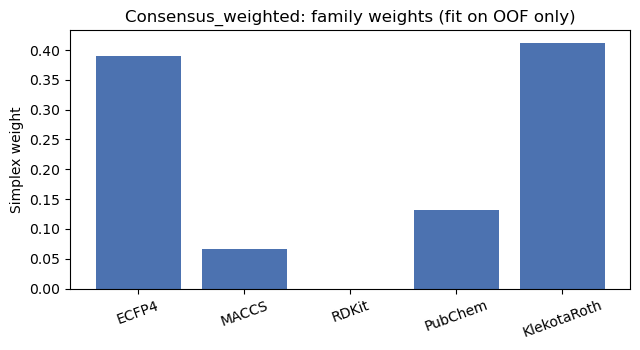

In [66]:
family_order = FAMILIES
P_tr = np.column_stack([preds[f]["train"] for f in family_order])
P_cv = np.column_stack([preds[f]["cv"] for f in family_order])
P_ts = np.column_stack([preds[f]["test"] for f in family_order])


def fit_simplex_weights(P, y):
    n = P.shape[1]

    def obj(w):
        return float(np.mean((P @ w - y) ** 2))

    cons = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    bounds = [(0.0, 1.0)] * n
    w0 = np.ones(n) / n
    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    w = np.clip(res.x, 0, 1)
    if w.sum() <= 0:
        w = w0
    else:
        w = w / w.sum()
    return w


if LOAD_TRAINED_MODELS and not FORCE_RETRAIN and (MODEL_DIR / "consensus_weights.pkl").is_file():
    w_cons, w_table, y_w_tr, y_w_cv, y_w_ts = load_consensus_workspace()
    print(f"Skipped consensus refit; loaded weights from {MODEL_DIR}")
else:
    w_cons = fit_simplex_weights(P_cv, y_tr)
    w_table = pd.DataFrame({"family": family_order, "weight": w_cons})
    display(w_table.round(4))
    w_table.to_csv(MODEL_DIR / "consensus_simplex_weights.csv", index=False)
    (MODEL_DIR / "consensus_simplex_weights.json").write_text(
        json.dumps({fam: float(w) for fam, w in zip(family_order, w_cons)}, indent=2),
        encoding="utf-8",
    )
    joblib.dump({"families": family_order, "weights": w_cons}, MODEL_DIR / "consensus_weights.pkl")

    y_w_tr = P_tr @ w_cons
    y_w_cv = P_cv @ w_cons
    y_w_ts = P_ts @ w_cons
    row = metrics_from_preds("Consensus_weighted", y_w_tr, y_w_cv, y_w_ts, in_ad)
    results.append(row)
    preds["Consensus_weighted"] = {"train": y_w_tr, "cv": y_w_cv, "test": y_w_ts}
    write_consensus_supplementary(y_w_tr, y_w_cv, y_w_ts)
    joblib.dump(results, RESULTS_PATH)
    write_workspace_meta("consensus")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(w_table["family"], w_table["weight"], color="#4C72B0")
ax.set_ylabel("Simplex weight")
ax.set_title("Consensus_weighted: family weights (fit on OOF only)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 9. Consensus SHAP interpretation

After `Consensus_weighted` is fitted or loaded, we explain predictions on the **concatenated SHAP–mRMR binary pools** of ECFP4, MACCS, PubChem and Klekota–Roth (766 pooled fingerprint bits in the current run; RDKit 2D descriptors are excluded from this unified fingerprint view, as for the applicability domain).

For each family CatBoost $f$, TreeSHAP values are computed on its pool matrix $X_f$ and scaled by the consensus weight $w_f$. Because the families use disjoint descriptor blocks,

$$\mathrm{SHAP}_{\mathrm{consensus}} = \big[\, w_{\mathrm{ECFP4}}\,\mathrm{SHAP}_{\mathrm{ECFP4}},\; w_{\mathrm{MACCS}}\,\mathrm{SHAP}_{\mathrm{MACCS}},\; w_{\mathrm{PubChem}}\,\mathrm{SHAP}_{\mathrm{PubChem}},\; w_{\mathrm{KlekotaRoth}}\,\mathrm{SHAP}_{\mathrm{KlekotaRoth}} \,\big].$$

For the top descriptors (`SHAP_TOP_DESCRIPTORS`, default 20) we also build an interpretation table with descriptor ID, SMARTS/pattern and a depiction of the matched fragment on a **training-set molecule** where the bit is on.

Results are saved to `consensus_shap_train.npz`, `consensus_shap_test.npz`, `consensus_shap_importance.csv` and `consensus_top_descriptors.csv` (PNG depictions in `descriptor_depictions/`).

Loaded consensus SHAP from models\ConsensusCatBoost
Consensus SHAP space: 766 pooled binary descriptors (200 ECFP4, 116 MACCS, 200 PubChem, 250 KlekotaRoth)

Top-20 descriptor interpretation (ID, SMARTS, training-set fragment):
Top descriptors: models\ConsensusCatBoost\consensus_top_descriptors.csv


,Rank,Descriptor,Family,SMARTS / pattern,Train ChEMBL,|SHAP|
0,1,KRFP1310,KlekotaRoth,[!#1]C(=O)[NH][OH],CHEMBL539664,0.0925
1,2,ECFP4_878,ECFP4,[#7]-[#8],CHEMBL539664,0.0834
2,3,ECFP4_1143,ECFP4,[#6]-[#6]-[#6]-[#6]-[#6],CHEMBL1767046,0.0161
3,4,PubchemFP514,PubChem,O-N-C-C,CHEMBL539664,0.0158
4,5,PubchemFP308,PubChem,O-H,CHEMBL1767046,0.0156
5,6,MACCS_68,MACCS,[!#6;!#1;!H0]~[!#6;!#1;!H0],CHEMBL539664,0.0145
6,7,KRFP3721,KlekotaRoth,CCCCCCC=O,CHEMBL1767046,0.0116
7,8,KRFP303,KlekotaRoth,[!#1][CH2][CH]([!#1])C(=O)[NH][!#1],CHEMBL1767046,0.0115
8,9,KRFP1570,KlekotaRoth,[!#1]c1[cH][cH][cH][cH]c1[NH2],CHEMBL3605493,0.0112
9,10,ECFP4_378,ECFP4,[#7],CHEMBL3605493,0.0105


Saved fragment grid: models\ConsensusCatBoost\consensus_top_descriptor_fragments.png (~3720px wide @ 300 dpi)
Figure. Top-20 molecular fingerprint descriptors ranked by mean absolute consensus-weighted SHAP on the training set. Each panel shows a representative training molecule (ChEMBL ID) with the structural substructure matched by that descriptor highlighted; panel headers give rank, descriptor ID, and SMARTS/pattern.


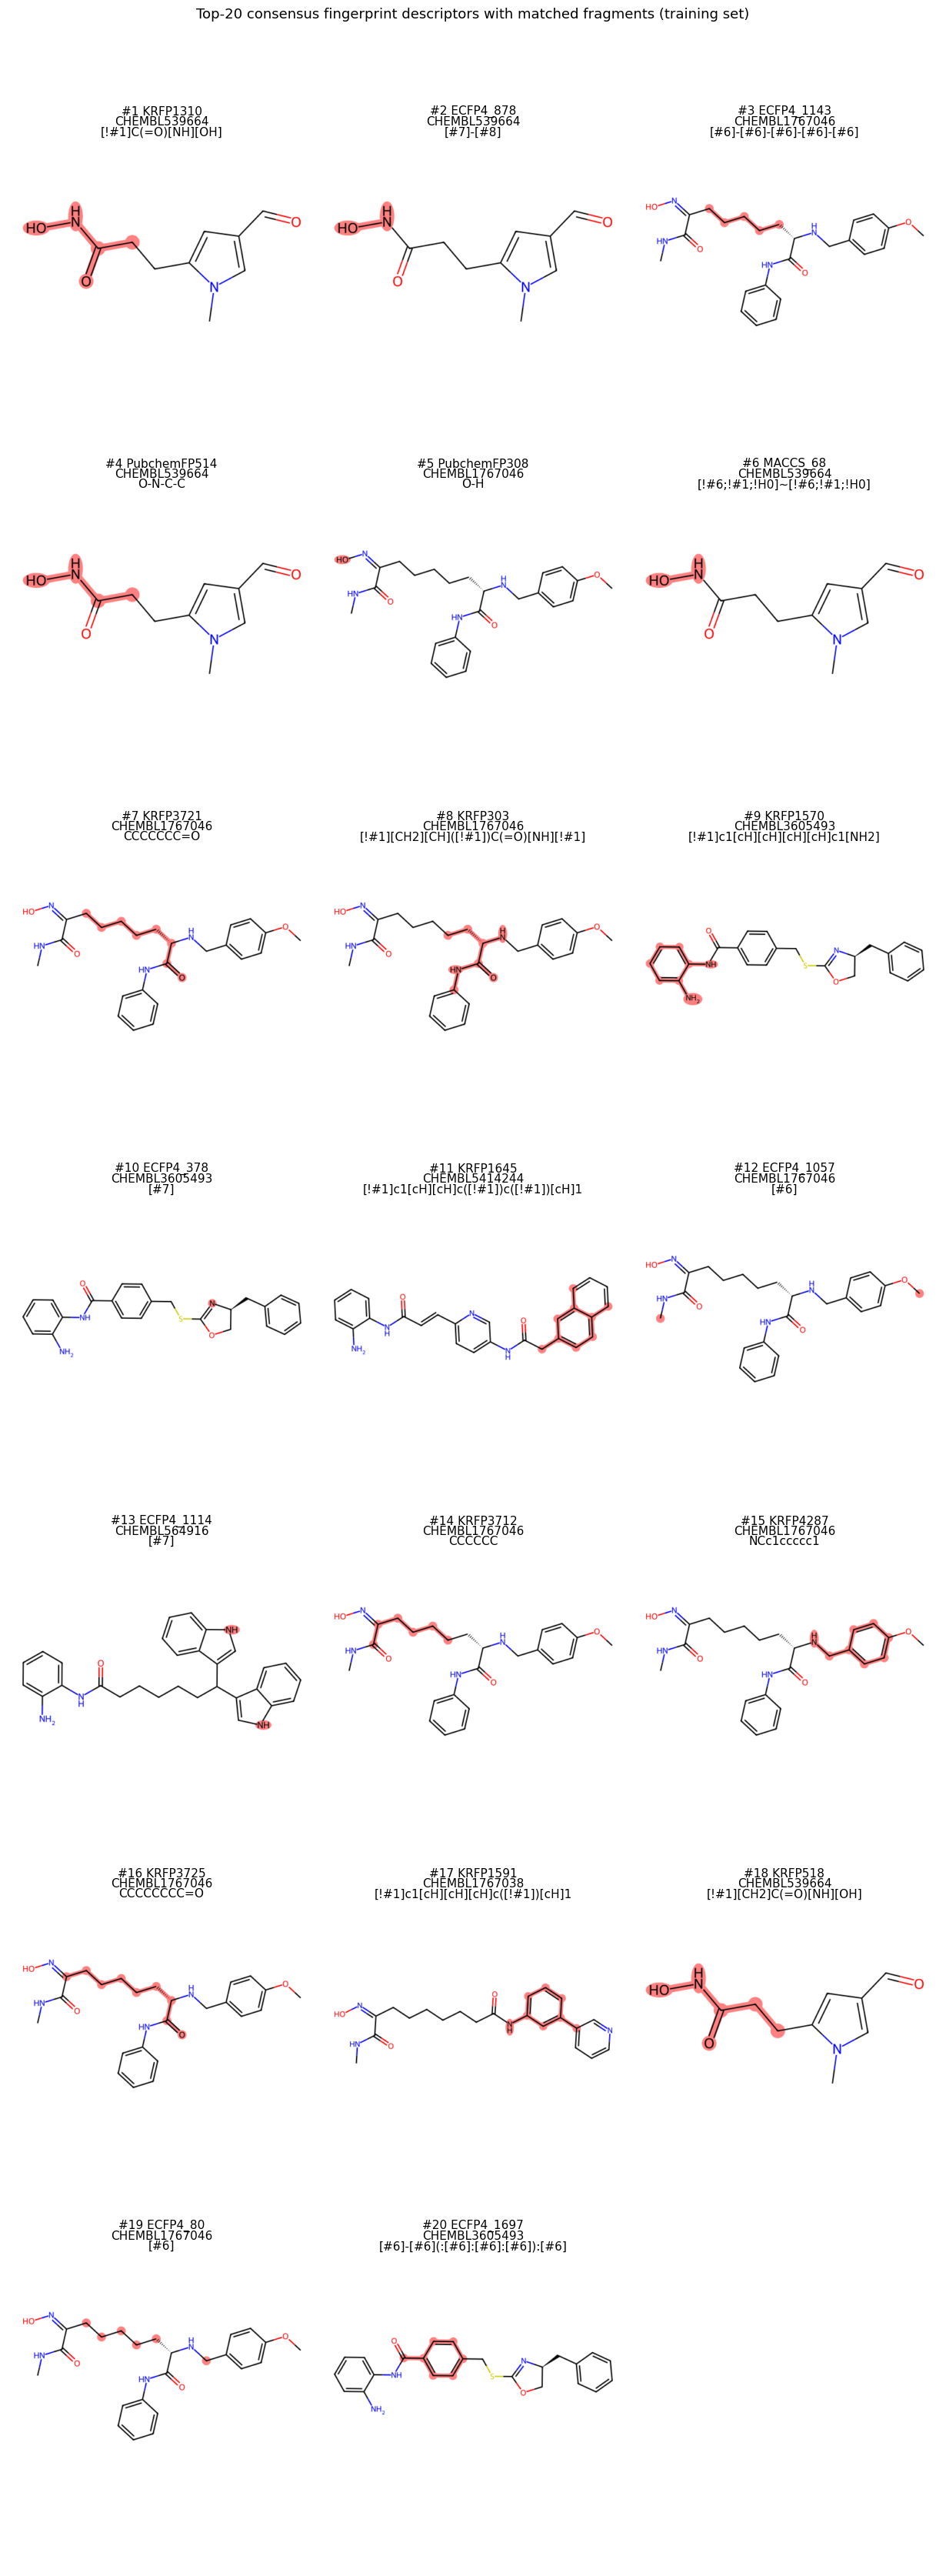

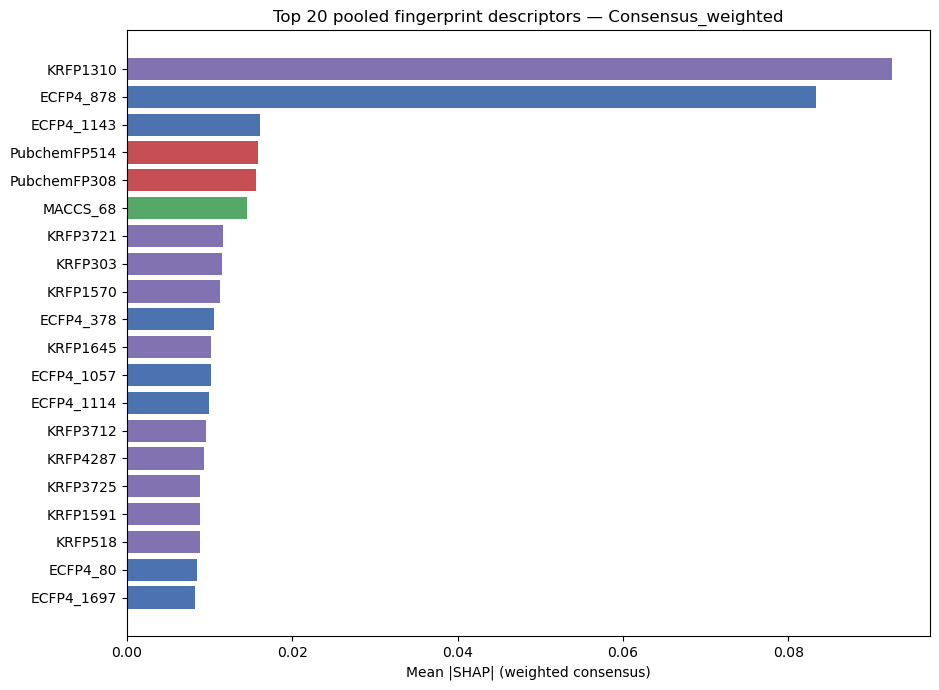

Saved beeswarm: models\ConsensusCatBoost\consensus_shap_beeswarm_train.png (~2400px wide @ 300 dpi)


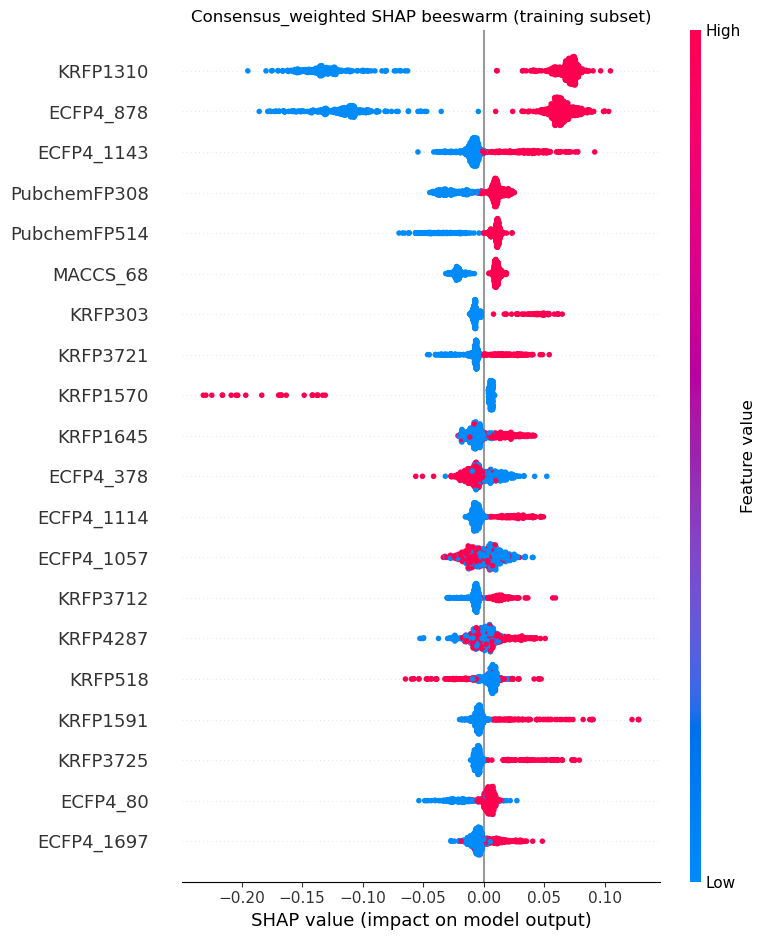

Family-level aggregated |SHAP| vs simplex weight:


,family,mean_abs_SHAP_consensus,SHAP_share,weight
0,KlekotaRoth,0.6968,0.4356,0.4124
1,ECFP4,0.5828,0.3644,0.3902
2,PubChem,0.2246,0.1405,0.1315
3,MACCS,0.0952,0.0595,0.0659


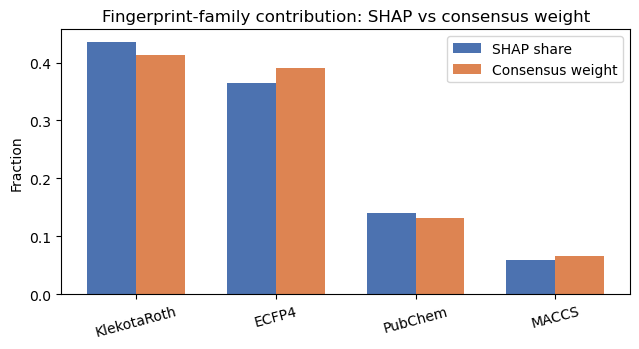

In [67]:
if not RUN_CONSENSUS_SHAP:
    print("Consensus SHAP skipped (RUN_CONSENSUS_SHAP=False).")
else:
    X_cons_tr, consensus_feature_names, consensus_slices = build_consensus_feature_blocks("train")
    X_cons_ts, _, _ = build_consensus_feature_blocks("test")
    consensus_descriptor_labels = descriptor_display_ids(consensus_feature_names)
    pool_sizes = {f: len(pools[f]["names"]) for f in BINARY_FAMILIES}

    if LOAD_TRAINED_MODELS and not FORCE_RETRAIN and consensus_shap_ready():
        shap_tr, shap_ts, consensus_feature_names, shap_importance = load_consensus_shap()
        consensus_descriptor_labels = descriptor_display_ids(consensus_feature_names)
        print(f"Loaded consensus SHAP from {MODEL_DIR}")
    else:
        X_by_tr = {fam: pools[fam]["X_tr"] for fam in BINARY_FAMILIES}
        X_by_ts = {fam: pools[fam]["X_ts"] for fam in BINARY_FAMILIES}
        print("Computing TreeSHAP for consensus on pooled binary descriptors...")
        shap_tr = compute_consensus_shap(X_by_tr)
        shap_ts = compute_consensus_shap(X_by_ts)
        shap_importance = consensus_shap_importance(shap_tr, consensus_feature_names)
        save_consensus_shap(shap_tr, shap_ts, consensus_feature_names, shap_importance)

    print(
        f"Consensus SHAP space: {len(consensus_feature_names)} pooled binary descriptors "
        f"({', '.join(f'{pool_sizes[f]} {f}' for f in BINARY_FAMILIES)})"
    )

    print(f"\nTop-{SHAP_TOP_DESCRIPTORS} descriptor interpretation (ID, SMARTS, training-set fragment):")
    top_descriptor_table = load_or_build_top_descriptor_table(
        shap_importance, top_n=SHAP_TOP_DESCRIPTORS
    )
    display_top_descriptor_table(top_descriptor_table)

    top = shap_importance.head(SHAP_TOP_DESCRIPTORS).iloc[::-1]
    colors = {"ECFP4": "#4C72B0", "MACCS": "#55A868", "PubChem": "#C44E52", "KlekotaRoth": "#8172B2"}
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    ax.barh(
        top["descriptor"],
        top["mean_abs_SHAP_consensus"],
        color=[colors.get(f, "#999999") for f in top["family"]],
    )
    ax.set_xlabel("Mean |SHAP| (weighted consensus)")
    ax.set_title(f"Top {SHAP_TOP_DESCRIPTORS} pooled fingerprint descriptors — Consensus_weighted")
    plt.tight_layout()
    plt.show()

    plot_n = min(SHAP_PLOT_SAMPLES, len(X_cons_tr))
    plot_idx = rng.choice(len(X_cons_tr), size=plot_n, replace=False)
    beeswarm_path = MODEL_DIR / "consensus_shap_beeswarm_train.png"
    beeswarm_dpi = 300
    beeswarm_min_width_px = 1700
    # figsize such that width_px = inches * dpi >= 1700 at save time
    beeswarm_fig_w = max(12.0, beeswarm_min_width_px / beeswarm_dpi)
    beeswarm_fig_h = beeswarm_fig_w * 0.72
    plt.figure(figsize=(beeswarm_fig_w, beeswarm_fig_h))
    shap.summary_plot(
        shap_tr[plot_idx],
        X_cons_tr[plot_idx],
        feature_names=consensus_descriptor_labels,
        max_display=SHAP_TOP_DESCRIPTORS,
        show=False,
    )
    plt.title("Consensus_weighted SHAP beeswarm (training subset)")
    plt.tight_layout()
    fig = plt.gcf()
    fig.savefig(
        beeswarm_path,
        dpi=beeswarm_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )
    out_w_px = int(fig.get_size_inches()[0] * beeswarm_dpi)
    print(f"Saved beeswarm: {beeswarm_path} (~{out_w_px}px wide @ {beeswarm_dpi} dpi)")
    plt.show()

    family_imp = (
        shap_importance.groupby("family", as_index=False)["mean_abs_SHAP_consensus"]
        .sum()
        .sort_values("mean_abs_SHAP_consensus", ascending=False)
    )
    family_imp["SHAP_share"] = family_imp["mean_abs_SHAP_consensus"] / family_imp["mean_abs_SHAP_consensus"].sum()
    family_summary = family_imp.merge(w_table, on="family", how="left")
    print("Family-level aggregated |SHAP| vs simplex weight:")
    display(family_summary.round(4))

    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    x = np.arange(len(family_summary))
    width = 0.35
    ax.bar(x - width / 2, family_summary["SHAP_share"], width, label="SHAP share", color="#4C72B0")
    ax.bar(x + width / 2, family_summary["weight"], width, label="Consensus weight", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(family_summary["family"], rotation=15)
    ax.set_ylabel("Fraction")
    ax.set_title("Fingerprint-family contribution: SHAP vs consensus weight")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Model comparison

Metrics are rounded to two decimals to match the manuscript table: training R²/RMSE, 5-fold Q²cv/RMSE, external Q²test/RMSE (all test compounds), AD coverage (Cov), Q²test/RMSE for compounds inside the applicability domain, and a Tropsha-style validity flag (`valid_tropsha`: Q² > 0.5, R²_ext > 0.6, |R²_ext − Q²| < 0.3).

If the notebook kernel was restarted, metrics are loaded from `models/ConsensusCatBoost/metrics_summary.csv` so family CatBoost models and `Consensus_weighted` do not need to be retrained.


,R2,RMSE,Q2cv,RMSE,Q2test,RMSE,Cov,Q2test,RMSE,valid_tropsha
model,,,,,,,,,,
CatBoost_ECFP4,0.93,0.24,0.59,0.56,0.60,0.57,0.77,0.70,0.50,True
CatBoost_MACCS,0.91,0.26,0.55,0.59,0.59,0.57,0.77,0.71,0.49,False
CatBoost_RDKit,0.95,0.19,0.54,0.60,0.60,0.56,0.77,0.71,0.49,True
CatBoost_PubChem,0.92,0.25,0.55,0.59,0.57,0.58,0.77,0.69,0.51,False
CatBoost_KlekotaRoth,0.88,0.31,0.59,0.56,0.57,0.59,0.77,0.68,0.51,False
Consensus_weighted,0.92,0.25,0.62,0.54,0.62,0.55,0.77,0.71,0.48,True


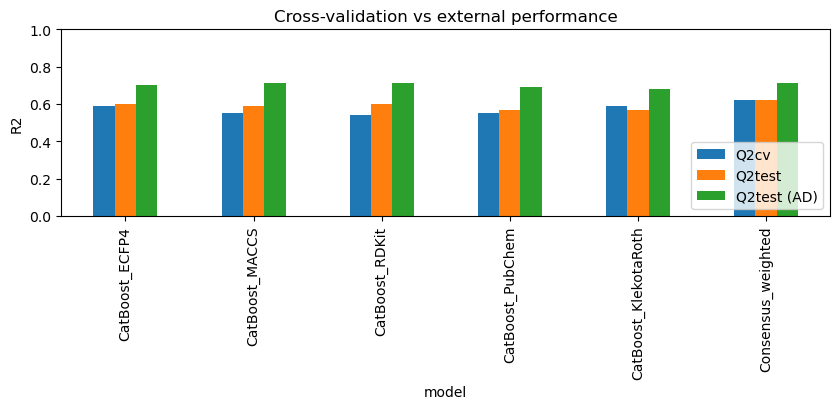

Best family CatBoost by external R2: CatBoost_RDKit
Best family CatBoost by Q2_CV: CatBoost_ECFP4
Consensus_weighted Q2_CV = 0.62, R2_ext = 0.62


In [56]:
metrics_path = MODEL_DIR / "metrics_summary.csv"

if "results" in globals() and results and all("Q2_CV" in r for r in results):
    summary = pd.DataFrame(results).set_index("model")
elif RESULTS_PATH.is_file():
    summary = pd.DataFrame(joblib.load(RESULTS_PATH)).set_index("model")
    print(f"Loaded cached metrics from {RESULTS_PATH}")
elif metrics_path.is_file():
    summary = pd.read_csv(metrics_path, index_col="model")
    print(f"Loaded cached metrics from {metrics_path}")
else:
    raise RuntimeError("No metrics in memory and no cached metrics_summary.csv found.")

if "Q2_CV" not in summary.columns:
    raise RuntimeError(
        f"{metrics_path} has display-only columns. Re-run family CatBoost / consensus cells "
        "or delete the CSV and reload from results.pkl / family_predictions.pkl."
    )

summary["valid_tropsha"] = (
    (summary["Q2_CV"] > 0.5)
    & (summary["R2_ext"] > 0.6)
    & ((summary["R2_ext"] - summary["Q2_CV"]).abs() < 0.3)
)

TABLE_COLS = [
    "R2_train",
    "RMSE_train",
    "Q2_CV",
    "RMSE_CV",
    "R2_ext",
    "RMSE_ext",
    "AD_coverage",
    "R2_ext_AD",
    "RMSE_ext_AD",
]
TABLE_HEADERS = [
    "R2",
    "RMSE",
    "Q2cv",
    "RMSE",
    "Q2test",
    "RMSE",
    "Cov",
    "Q2test",
    "RMSE",
]

table = summary[TABLE_COLS].copy()
table.columns = TABLE_HEADERS
table = table.round(2)
table["valid_tropsha"] = summary["valid_tropsha"].values

display(table)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
summary[["Q2_CV", "R2_ext", "R2_ext_AD"]].round(2).rename(
    columns={"Q2_CV": "Q2cv", "R2_ext": "Q2test", "R2_ext_AD": "Q2test (AD)"},
).plot(kind="bar", ax=ax)
ax.set_ylabel("R2")
ax.set_ylim(0, 1)
ax.set_title("Cross-validation vs external performance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

family_rows = summary.drop(index=["Consensus_weighted"], errors="ignore")
print("Best family CatBoost by external R2:", family_rows["R2_ext"].idxmax())
print("Best family CatBoost by Q2_CV:", family_rows["Q2_CV"].idxmax())
if "Consensus_weighted" in summary.index:
    print(
        "Consensus_weighted Q2_CV = {:.2f}, R2_ext = {:.2f}".format(
            summary.loc["Consensus_weighted", "Q2_CV"],
            summary.loc["Consensus_weighted", "R2_ext"],
        )
    )

# Persist full internal column names (not the display-renamed table), so reload stays valid.
summary.round(6).to_csv(metrics_path)
if "results" in globals() and results:
    joblib.dump(results, RESULTS_PATH)
if "studies" in globals() and studies:
    joblib.dump({k: v.best_params for k, v in studies.items()}, MODEL_DIR / "best_params.pkl")
    joblib.dump(studies, MODEL_DIR / "optuna_studies.pkl")


## 11. Y-randomization

`permutation_test_score` shuffles the training endpoint and repeats CV on each family CatBoost. A real structure–activity relationship should give a high true $Q^2$ and a near-zero (or negative) mean randomized score. `Consensus_weighted` has no single sklearn estimator (it is a simplex combination of the five OOF predictors), so the test is run on the family members that actually see the descriptors.


In [ ]:
y_rand_path = MODEL_DIR / "y_randomization.csv"

if not RUN_Y_RANDOMIZATION:
    print("Y-randomization skipped (RUN_Y_RANDOMIZATION=False).")
elif LOAD_TRAINED_MODELS and not FORCE_RETRAIN and y_rand_path.is_file():
    y_rand = pd.read_csv(y_rand_path, index_col=0)
    display(y_rand.round(4))
    print(f"Loaded Y-randomization results from {y_rand_path}")
else:
    y_rand_rows = []
    for fam in FAMILIES:
        est = fitted[fam]
        X_ = pools[fam]["X_tr"]
        score, perm_scores, pvalue = permutation_test_score(
            clone(est),
            X_,
            y_tr,
            cv=cv_final,
            scoring="r2",
            n_permutations=N_PERMUTATIONS,
            n_jobs=1,
            random_state=SEED,
            params={"verbose": False},
        )
        y_rand_rows.append(
            {
                "model": f"CatBoost_{fam}",
                "true_Q2": score,
                "y_rand_mean": float(np.mean(perm_scores)),
                "y_rand_std": float(np.std(perm_scores)),
                "p_value": float(pvalue),
            }
        )
        print(
            f"{fam}: true Q2 = {score:.3f}, "
            f"Y-randomization = {np.mean(perm_scores):.3f} +/- {np.std(perm_scores):.3f}, "
            f"p = {pvalue:.4f}"
        )

    y_rand = pd.DataFrame(y_rand_rows).set_index("model")
    display(y_rand.round(4))
    y_rand.round(4).to_csv(y_rand_path)


ECFP4: true Q2 = 0.591, Y-randomization = -0.233 +/- 0.021, p = 0.0476
MACCS: true Q2 = 0.551, Y-randomization = -0.259 +/- 0.020, p = 0.0476
RDKit: true Q2 = 0.538, Y-randomization = -0.168 +/- 0.020, p = 0.0476
PubChem: true Q2 = 0.547, Y-randomization = -0.244 +/- 0.023, p = 0.0476
KlekotaRoth: true Q2 = 0.590, Y-randomization = -0.222 +/- 0.019, p = 0.0476


,true_Q2,y_rand_mean,y_rand_std,p_value
model,,,,
CatBoost_ECFP4,0.5907,-0.2330,0.0208,0.0476
CatBoost_MACCS,0.5508,-0.2586,0.0198,0.0476
CatBoost_RDKit,0.5376,-0.1684,0.0204,0.0476
CatBoost_PubChem,0.5468,-0.2441,0.0232,0.0476
CatBoost_KlekotaRoth,0.5900,-0.2216,0.0188,0.0476
